# An ATLAS global fit on the IPTA Mock Data Challenge 1 (Open Dataset 1)

### Same machinery as `three_pulsar_global_fit.ipynb` and `ten_pulsar_sim_global_fit.ipynb` — GWB, intrinsic red noise, and a directly-sampled linear timing model — but on a dataset simple enough that a wrong answer means a wrong pipeline

`three_pulsar_global_fit.ipynb` teaches the machinery. `ten_pulsar_sim_global_fit.ipynb` runs it on
a NANOGrav-realistic simulation — DMX, per-backend EFAC/EQUAD/ECORR, ~178k TOAs, a GWB buried at
the realistic $A \sim 2.4\times10^{-15}$ level. That realism is exactly what makes it a poor first
pipeline test: if a NUTS run looks wrong, you cannot tell whether the *code* is wrong or the
*inference problem* is simply hard.

This notebook is deliberately the opposite. It runs the same ATLAS global fit on the
**IPTA Mock Data Challenge 1, Open Dataset 1** (Verbiest et al. 2010 "open" challenge; still
shipped today as package data inside `enterprise-pulsar`, at
`enterprise/datafiles/mdc_open1/`), which was designed to be trivial to detect:

| Property | MDC1 Open 1 | `sim_NG15_01` for comparison |
|---|---|---|
| Pulsars | **all 36** | 10 (of 67 available) |
| White noise | **homogeneous** — every pulsar has the same TOA uncertainty (0.1 μs), one "backend", no EFAC/EQUAD/ECORR | per-backend EFAC/EQUAD/ECORR, drawn from a distribution |
| Intrinsic red noise | **none injected** | per-pulsar power law at NG15 ML values |
| GWB | one strongly-correlated power law at $A = 5\times10^{-14}$, $\gamma = 13/3$ — ~20× the realistic level | $A = 2.4\times10^{-15}$, $\gamma = 13/3$ (the realistic level) |
| Timing model | isolated-pulsar astrometry/spin (~8 columns), or +binary (~10–17) — no DMX, no JUMPs | full NANOGrav design matrix incl. DMX (100+ columns) |
| Cadence / baseline | ~130 TOAs per pulsar, ~14-day cadence, ~5 yr | NANOGrav 15 yr cadence and baselines |

None of the ATLAS machinery changes — it is the *same* four-signal model (linear timing model,
white noise, intrinsic red noise, GWB) built exactly the same way. What changes is that every
nuisance parameter that usually eats posterior volume and wall-clock time (EFAC/EQUAD/ECORR,
DMX, a >150-column padded design matrix) is either absent or tiny. So the answer is known, the
run takes minutes, and any discrepancy is a pipeline bug rather than a hard inference problem.

**The result, up front.** With all 36 pulsars (630 Hellings–Downs pairs), 700 warmup + 700
samples, fitting one EFAC and one EQUAD per pulsar alongside the GWB (~10 min on one GPU):

$$\log_{10}A_\mathrm{GWB} = -13.296 \pm 0.021 \qquad \gamma_\mathrm{GWB} = 4.30 \pm 0.115$$

against the design values $\log_{10}(5\times10^{-14}) = -13.301$ and $13/3 = 4.333$. Both within
$0.3\sigma$. Zero divergences.

---

## ⚠️ The one thing to intern: this dataset will silently destroy itself if you read it with PINT

An earlier version of this notebook reported the GWB at $\log_{10}A \approx -8.5$ — **five orders
of magnitude** too loud — with a NUTS chain frozen at a step size of $1.5\times10^{-13}$. None of
that was ATLAS's fault. The MDC1 par files are written in **TCB** but carry no `UNITS` line;
tempo2's default is TCB, PINT's default is TDB, so PINT mis-scales `F0` by
$L_B \approx 1.55\times10^{-8}$, accumulating ~500 turns of phase over the 4.94 yr baseline.
PINT's `track_mode="nearest"` then wraps that away and the residuals come out as a **uniform
random hash over one pulse period**. §1a shows the smoking gun and the fix.

So this notebook loads the data with **tempo2/libstempo**, which reads TCB natively — and, as a
bonus, reads the `BINARY T2` model that PINT cannot parse, so all **36** pulsars are usable
rather than the 26 PINT can manage.

**Two toggles.** `VARY_WHITE_NOISE` in §2 chooses between taking the 0.1 μs TOA uncertainties at
face value (zero white-noise parameters) and fitting **one EFAC and one EQUAD per pulsar**.
§2a derives that model from the TOA timestamps themselves, and shows why an ECORR would be
strictly unidentifiable on this dataset rather than merely unnecessary.

**The pulsar count is the other toggle.** Set `NUM_PSRS` in §1 to anything from 2 to 36 and re-run
from there — everything downstream (bin counts, priors, initial values, the sampler call) is
written in terms of `NUM_PSRS`/`data.npsrs`, not a hardcoded list length. Watch the GWB posterior
sharpen and the pair count grow as $N(N-1)/2$.

---
## 0. Prerequisites

ATLAS needs `jax`, `numpyro`, `enterprise-pulsar`, `scikit-learn`, `joblib`, `tqdm`,
`tqdm_joblib`, and **JUG**.

> **Note.** `pyproject.toml` under-declares its dependencies: `scikit-learn`, `tqdm` and
> `tqdm_joblib` are hard imports on the main path but are not listed as runtime requirements,
> and JUG is not on PyPI. `ATLAS.model_builder` imports `ATLAS.signals.timing.base`, which
> imports JUG at module level — so **you need JUG installed even for an analysis like this one
> that never uses the nonlinear timing model.** Install it from source alongside ATLAS.

**This notebook additionally needs `libstempo` (and therefore tempo2)** — see the warning above.
PINT alone cannot read this dataset correctly. If you are on conda:

```bash
# tempo2 in its own prefix, so it cannot disturb a working ATLAS environment
conda create -y -p $CONDA_PREFIX/../tempo2lib -c conda-forge tempo2
# build only the small libstempo extension into the ATLAS env
TEMPO2_PREFIX=$CONDA_PREFIX/../tempo2lib pip install libstempo
```

libstempo locates tempo2's clock/ephemeris files through the **`TEMPO2` environment variable**,
which must point at the runtime data directory (`.../share/tempo2`). The next cell finds it for
you if it is already set or discoverable; otherwise set it yourself. To make it permanent:

```bash
mkdir -p $CONDA_PREFIX/etc/conda/activate.d
echo 'export TEMPO2=<prefix>/share/tempo2' > $CONDA_PREFIX/etc/conda/activate.d/tempo2.sh
```

The par/tim files themselves ship *inside* `enterprise-pulsar`, so there is no download step.

In [1]:
import os, sys, glob, pickle, time

# Do this before jax initialises: without it the parent process grabs most of the GPU up
# front and the joblib workers that load pulsars in section 1 die with CUDA OOM.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

# --- locate tempo2's runtime data directory for libstempo -------------------------------
def _find_tempo2_runtime():
    if os.environ.get("TEMPO2") and os.path.isdir(os.environ["TEMPO2"]):
        return os.environ["TEMPO2"]
    import shutil
    exe = shutil.which("tempo2")
    cands = []
    if exe:
        cands.append(os.path.join(os.path.dirname(os.path.dirname(exe)), "share", "tempo2"))
    cands += glob.glob(os.path.join(sys.prefix, "..", "*", "share", "tempo2"))
    cands += glob.glob(os.path.join(sys.prefix, "share", "tempo2"))
    for c in cands:
        if os.path.isdir(c):
            return os.path.abspath(c)
    return None

_t2 = _find_tempo2_runtime()
assert _t2 is not None, (
    "Could not locate tempo2's runtime data directory. Install tempo2 (see section 0) and "
    "set the TEMPO2 environment variable to its .../share/tempo2 directory."
)
os.environ["TEMPO2"] = _t2

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)   # ATLAS assumes float64 everywhere
import jax.numpy as jnp
import jax.random as jrandom

import numpyro
from numpyro.infer import MCMC, NUTS, init_to_value

sys.path.append("..")   # so `import ATLAS` works when running from notebooks/

import libstempo
from ATLAS.data import PTA_Data
from ATLAS.pulsar import load_pulsars
from ATLAS.model_builder import ModelBuilder
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.psd_functions import powerlaw, hd_orf
from ATLAS.samplers.canetoadracing import model_maker

print("jax", jax.__version__, "| numpyro", numpyro.__version__, "| libstempo", libstempo.__version__)
print("TEMPO2 =", os.environ["TEMPO2"])
print("devices:", jax.devices())

/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/coronus/miniconda3/envs/atlas/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


jax 0.10.1 | numpyro 0.21.0 | libstempo 2.5.1
TEMPO2 = /home/coronus/miniconda3/envs/tempo2lib/share/tempo2
devices: [CudaDevice(id=0)]


---
# 1. Data → `Pulsar` objects

`ATLAS.pulsar.Pulsar` wraps `enterprise.pulsar.Pulsar` behind ATLAS's own thin interface. It
extracts TOAs, residuals, TOA errors, radio frequencies, backend flags, sky position, and —
crucially — the **linearised timing design matrix** $M$.

Which timing backend enterprise uses underneath is a `timing_package=` argument, and on this
dataset **it is not a matter of taste**. See §1a.

## Where this dataset lives

The 36 par/tim pairs are package data shipped inside `enterprise-pulsar` itself, at
`enterprise/datafiles/mdc_open1/`. We locate them programmatically from the installed package
rather than hardcoding a path.

## The toggle

`NUM_PSRS` below is the **only** thing you need to change to scale this analysis up or down.
Pulsar J-names encode right ascension (`JHHMM...`), so sorting the 36 names alphabetically and
taking the first `NUM_PSRS` gives a reasonable spread in RA "for free" even at small `NUM_PSRS`
— useful, since Hellings–Downs sensitivity depends on having pulsar *pairs* spread across sky
separation angle. §1d plots the sky positions you actually got so you can check this instead of
taking it on faith.

Caching is keyed by `NUM_PSRS`, so toggling it and re-running triggers a fresh (parallel) load
only the first time you use a given pulsar count.

In [2]:
import enterprise

# ============================================================================
# TOGGLE: how many MDC1 Open-1 pulsars to include in the analysis.
# Everything below is written in terms of NUM_PSRS / data.npsrs -- change this
# and re-run from here down. Valid range: 2-36.
NUM_PSRS = 36
# ============================================================================

MDC_DIR = os.path.join(os.path.dirname(enterprise.__file__), "datafiles", "mdc_open1")
assert os.path.isdir(MDC_DIR), (
    f"Couldn't find the MDC1 Open-1 package data at {MDC_DIR}. "
    "It ships inside enterprise-pulsar >= 3.x as enterprise/datafiles/mdc_open1/; "
    "check your enterprise-pulsar installation/version."
)

def binary_model(parfile):
    'Return the BINARY model name in a par file, or None for isolated pulsars.'
    for line in open(parfile):
        if line.strip().startswith("BINARY"):
            return line.split()[1]
    return None

ALL_PSR_NAMES = sorted(os.path.basename(f)[:-4] for f in glob.glob(f"{MDC_DIR}/*.par"))
BINARY = {n: binary_model(f"{MDC_DIR}/{n}.par") for n in ALL_PSR_NAMES}

_t2only = sorted(n for n, b in BINARY.items() if b == "T2")
print(f"{len(ALL_PSR_NAMES)} pulsars in the dataset")
print(f"  isolated            : {sum(1 for b in BINARY.values() if b is None)}")
print(f"  BT / DD / ELL1      : {sum(1 for b in BINARY.values() if b not in (None, 'T2'))}")
print(f"  BINARY T2           : {len(_t2only)}  <- readable by tempo2 only, PINT cannot parse these")
print(f"                        {_t2only}")

assert 2 <= NUM_PSRS <= len(ALL_PSR_NAMES), f"NUM_PSRS must be between 2 and {len(ALL_PSR_NAMES)}"
PSR_NAMES = ALL_PSR_NAMES[:NUM_PSRS]

parfiles = [f"{MDC_DIR}/{p}.par" for p in PSR_NAMES]
timfiles = [f"{MDC_DIR}/{p}.tim" for p in PSR_NAMES]

print(f"\nusing {NUM_PSRS} of {len(ALL_PSR_NAMES)} pulsars")

36 pulsars in the dataset
  isolated            : 7
  BT / DD / ELL1      : 19
  BINARY T2           : 10  <- readable by tempo2 only, PINT cannot parse these
                        ['J0613-0200', 'J1022+1001', 'J1045-4509', 'J1600-3053', 'J1603-7202', 'J1643-1224', 'J1732-5049', 'J1909-3744', 'J2129-5721', 'J2145-0750']

using 36 of 36 pulsars


## 1a. ⚠️ Why tempo2 and not PINT: the TCB trap, and how to catch it

Look at an MDC1 par file:

```
PSRJ           J0030+0451
F0             205.53069608827312545     1  1.67e-13
...
EPHVER         5
CLK            UNCORR
MODE 1
EPHEM          DE414
```

There is **no `UNITS` line**. tempo2's default in that case is **TCB**; PINT's default is
**TDB**. The two timescales differ in rate by $L_B \approx 1.55\times10^{-8}$, so reading a TCB
`F0` as TDB mis-scales it by $\Delta F_0 = 205.53 \times 1.55\times10^{-8} \approx
3.2\times10^{-6}$ Hz. Over the 4.94 yr baseline ($1.56\times10^{8}$ s) that is **~500 turns** of
accumulated phase, i.e. ~3.9 turns between adjacent 14-day TOAs.

Three things then conspire to hide the damage:

1. PINT's residuals use `track_mode="nearest"`, which subtracts the nearest integer pulse
   number — so a 500-turn error is **wrapped** into $(-P/2, +P/2]$.
2. enterprise never refits, so nothing recovers it.
3. The wrap is *nonlinear*, so the linear timing design matrix cannot absorb it either.
   Least-squares fitting the full $M$ removes less than 0.5% of the variance.

The result is residuals that are a **uniform random number over one pulse period** — pure noise
that a global fit will happily interpret as an enormously loud GWB.

**The diagnostic is a one-liner: compare the residual RMS to $P/\sqrt{12}$.** If they agree, your
residuals are a phase hash and nothing downstream means anything. Run it below on both backends.

J0030+0451:  spin period P = 4.865 ms   ->   P/sqrt(12) = 1404.5 us
                          RMS (us)    RMS / (P/sqrt12)                   verdict
  PINT  (reads as TDB)    1406.736               1.002     PHASE HASH - unusable
 tempo2 (reads as TCB)       1.049               0.001                        ok


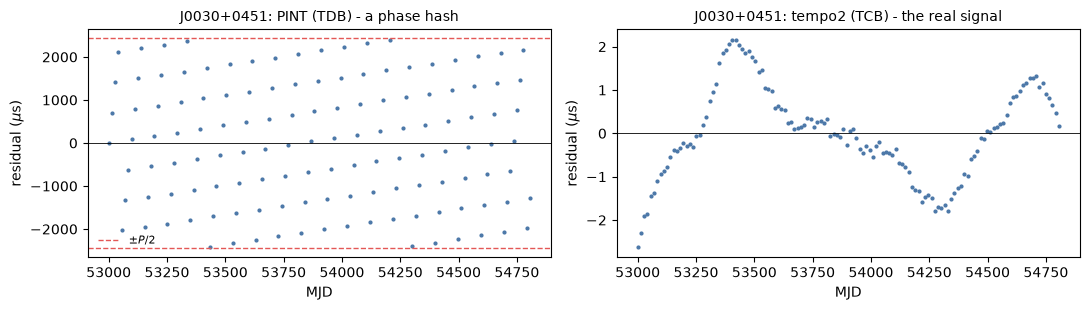

In [3]:
import pint.logging; pint.logging.setup(level="ERROR")
from pint.models import get_model
from pint.toa import get_TOAs
from pint.residuals import Residuals

demo = PSR_NAMES[0]
P = 1.0 / get_model(f"{MDC_DIR}/{demo}.par").F0.value      # spin period, seconds

# --- how PINT reads it (TDB assumed) ---
_m = get_model(f"{MDC_DIR}/{demo}.par")
_t = get_TOAs(f"{MDC_DIR}/{demo}.tim", model=_m, planets=False)
r_pint = np.asarray(Residuals(_t, _m).time_resids.to("us").value, dtype=float)

# --- how tempo2 reads it (TCB, correctly) ---
_lt = libstempo.tempopulsar(parfile=f"{MDC_DIR}/{demo}.par", timfile=f"{MDC_DIR}/{demo}.tim")
r_t2 = np.asarray(_lt.residuals()) * 1e6

print(f"{demo}:  spin period P = {P*1e3:.3f} ms   ->   P/sqrt(12) = {P/np.sqrt(12)*1e6:.1f} us")
print(f"{'':>22}{'RMS (us)':>12}{'RMS / (P/sqrt12)':>20}{'verdict':>26}")
for label, r in [("PINT  (reads as TDB)", r_pint), ("tempo2 (reads as TCB)", r_t2)]:
    ratio = r.std() / (P / np.sqrt(12) * 1e6)
    verdict = "PHASE HASH - unusable" if 0.9 < ratio < 1.1 else "ok"
    print(f"{label:>22}{r.std():>12.3f}{ratio:>20.3f}{verdict:>26}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)
for ax, (label, r) in zip(axes, [("PINT (TDB) - a phase hash", r_pint),
                                 ("tempo2 (TCB) - the real signal", r_t2)]):
    ax.plot(np.asarray(_t.get_mjds().value, dtype=float), r, ".", ms=4, color="#4c78a8")
    ax.axhline(0, lw=.6, color="k")
    ax.set_title(f"{demo}: {label}", fontsize=10)
    ax.set_xlabel("MJD"); ax.set_ylabel(r"residual ($\mu$s)")
axes[0].axhline( P/2*1e6, ls="--", lw=1, color="#e45756", label=r"$\pm P/2$")
axes[0].axhline(-P/2*1e6, ls="--", lw=1, color="#e45756")
axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

The left panel fills the band $\pm P/2$ uniformly; the right panel is a ~1 μs red-ish wander,
which is what a $A = 5\times10^{-14}$ GWB on a 0.1 μs array actually looks like.

### If you must use PINT

Appending `UNITS TCB` to each par file and loading with
`get_model(par, allow_tcb=True)` makes PINT convert to TDB and gives residuals within ~10% of
tempo2's for most pulsars. It is still the worse option here, because it does not help with the
ten `BINARY T2` pulsars, and its conversion of some binary parameters is approximate (J0711-6830
comes out at 3.3 μs via that route versus 0.75 μs via tempo2). We use tempo2 throughout.

### Loading

`ATLAS.pulsar.load_pulsars` now takes a `timing_package` argument and pairs par/tim files by
basename-without-extension, so plainly-named datasets like this one work through the convenience
wrapper.

In [4]:
CACHE = f"psrs_mdc1_t2_{NUM_PSRS}psr.pkl"

if os.path.exists(CACHE):
    psrs = pickle.load(open(CACHE, "rb"))
    print(f"loaded {len(psrs)} pulsars from cache {CACHE}")
else:
    t0 = time.time()
    psrs = load_pulsars(parfiles, timfiles, use_enterprise=True, timing_package="tempo2")
    print(f"loaded {len(psrs)} pulsars in {time.time() - t0:.1f} s")
    pickle.dump(psrs, open(CACHE, "wb"))

loaded 36 pulsars from cache psrs_mdc1_t2_36psr.pkl


In [5]:
YR = 365.25 * 86400.0
print(f"{'pulsar':<12} {'BINARY':>7} {'nTOA':>6} {'Tspan/yr':>9} {'M cols':>7} {'backends':>9}")
for p in psrs:
    print(f"{p.name:<12} {str(BINARY[p.name] or '-'):>7} {len(p.toas):>6} "
          f"{(p.toas.max() - p.toas.min()) / YR:>9.2f} "
          f"{p.Mmat.shape[1]:>7} {len(set(p.backend_flags)):>9}")

pulsar        BINARY   nTOA  Tspan/yr  M cols  backends


J0030+0451         -    130      4.94       8         1
J0218+4232      ELL1    130      4.94      11         1
J0437-4715        DD    130      4.94      17         1
J0613-0200        T2    130      4.94      13         1
J0621+1002        BT    130      4.94      14         1
J0711-6830         -    130      4.94       8         1
J0751+1807      ELL1    130      4.94      12         1
J0900-3144        BT    130      4.94      11         1
J1012+5307      ELL1    130      4.94      13         1
J1022+1001        T2    130      4.94      13         1
J1024-0719         -    130      4.94       8         1
J1045-4509        T2    130      4.94      13         1
J1455-3330      ELL1    130      4.94      13         1
J1600-3053        T2    130      4.94      15         1
J1603-7202        T2    130      4.94      15         1
J1640+2224        DD    130      4.94      14         1
J1643-1224        T2    130      4.94      14         1
J1713+0747        DD    130      4.94      14   

Notice: exactly one "backend" per pulsar (the `.tim` files carry no backend flags at all, so
enterprise reports a single unnamed system), and $M$ has ~8 columns for isolated pulsars or
10–17 for the binaries — no DMX, no JUMPs. This is the "no timing-model complexity to speak of"
half of what makes this dataset a clean pipeline test.

## 1b. Confirming the noise is actually homogeneous

Don't take the docstring's word for it — check.

In [6]:
toaerr_us = {p.name: np.unique(np.round(np.asarray(p.toaerrs) * 1e6, 6)) for p in psrs}
print("distinct TOA-uncertainty values (microseconds) per pulsar:")
for name, v in list(toaerr_us.items())[:6]:
    print(f"  {name:<12} {v}")
print(f"  ... ({len(toaerr_us)} pulsars total)")
assert all(len(v) == 1 for v in toaerr_us.values()), "expected exactly one TOA-error value per pulsar"

all_values = np.unique(np.concatenate(list(toaerr_us.values())))
print(f"\ndistinct TOA-uncertainty values across the whole selected sub-array: {all_values} us")
print("-> single value across all selected pulsars: white noise here really is just sigma_i,",
      "no EFAC/EQUAD/ECORR needed to describe it.")

distinct TOA-uncertainty values (microseconds) per pulsar:
  J0030+0451   [0.1]
  J0218+4232   [0.1]
  J0437-4715   [0.1]
  J0613-0200   [0.1]
  J0621+1002   [0.1]
  J0711-6830   [0.1]
  ... (36 pulsars total)

distinct TOA-uncertainty values across the whole selected sub-array: [0.1] us
-> single value across all selected pulsars: white noise here really is just sigma_i, no EFAC/EQUAD/ECORR needed to describe it.


## 1c. The residual scale — and the phase-hash guard, applied to every pulsar

The GWB in this dataset is loud, so the residuals should sit well above the 0.1 μs TOA
uncertainty — but *only* by about an order of magnitude, not four. The assertion below is the
§1a diagnostic turned into a guard: if any pulsar's residual RMS lands within 10% of
$P/\sqrt{12}$, the load is broken and the notebook stops rather than producing a confident
wrong answer.

In [7]:
F0s = {}
for n in PSR_NAMES:
    for line in open(f"{MDC_DIR}/{n}.par"):
        if line.split() and line.split()[0] == "F0":
            F0s[n] = float(line.split()[1])

print(f"{'pulsar':<12} {'toaerr (us)':>12} {'RMS (us)':>10} {'RMS/toaerr':>11} {'P/sqrt12 (us)':>14} {'ratio':>7}")
bad = []
for p in psrs:
    sigma = float(np.asarray(p.toaerrs)[0]) * 1e6
    rms   = float(np.std(np.asarray(p.residuals))) * 1e6
    hash_level = 1.0 / F0s[p.name] / np.sqrt(12) * 1e6
    ratio = rms / hash_level
    if 0.9 < ratio < 1.1:
        bad.append(p.name)
    print(f"{p.name:<12} {sigma:>12.3f} {rms:>10.3f} {rms/sigma:>10.1f}x {hash_level:>14.1f} {ratio:>7.3f}")

assert not bad, (
    f"Residual RMS is consistent with a uniform hash over one pulse period for: {bad}. "
    "The timing solution is not being tracked -- see section 1a (TCB/TDB)."
)
print(f"\nOK: no pulsar's residuals look like a phase hash.")
print(f"median RMS = {np.median([float(np.std(np.asarray(p.residuals)))*1e6 for p in psrs]):.2f} us,"
      f" i.e. ~{np.median([float(np.std(np.asarray(p.residuals)))*1e6 for p in psrs])/0.1:.0f}x the TOA-error floor.")
print("That excess is what the global fit below has to explain -- correlated GWB, per-pulsar red")
print("noise, or both. Untangling it is the point of running the fit, not a foregone conclusion.")

pulsar        toaerr (us)   RMS (us)  RMS/toaerr  P/sqrt12 (us)   ratio
J0030+0451          0.100      1.049       10.5x         1404.5   0.001
J0218+4232          0.100      1.422       14.2x          670.6   0.002
J0437-4715          0.100      0.499        5.0x         1662.0   0.000
J0613-0200          0.100      2.507       25.1x          883.9   0.003
J0621+1002          0.100      1.089       10.9x         8329.4   0.000
J0711-6830          0.100      0.746        7.5x         1585.1   0.000
J0751+1807          0.100      1.136       11.4x         1004.2   0.001
J0900-3144          0.100      0.653        6.5x         3207.1   0.000
J1012+5307          0.100      0.486        4.9x         1517.2   0.000
J1022+1001          0.100      0.701        7.0x         4749.6   0.000
J1024-0719          0.100      0.653        6.5x         1490.2   0.000
J1045-4509          0.100      0.955        9.6x         2157.6   0.000
J1455-3330          0.100      0.735        7.3x         2305.7 

## 1d. Sky coverage — why the pulsar count matters for Hellings–Downs

A single pulsar carries no correlation information; you need *pairs*, spread across angular
separation, to trace out the Hellings–Downs curve at all. Pair count grows as $N(N-1)/2$ —
3 pulsars give 3 pairs, 5 give 10, 10 give 45, all 36 give **630**.

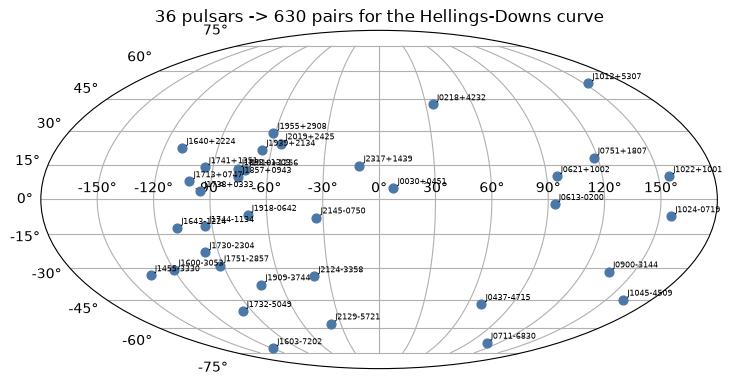

In [8]:
raj  = np.array([float(p.raj)  for p in psrs])   # radians, [0, 2pi)
decj = np.array([float(p.decj) for p in psrs])   # radians, [-pi/2, pi/2]
lon  = ((raj + np.pi) % (2 * np.pi)) - np.pi     # wrap into [-pi, pi] for mollweide

npairs = NUM_PSRS * (NUM_PSRS - 1) // 2

fig = plt.figure(figsize=(7.5, 4.2))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(lon, decj, s=40, color="#4c78a8", zorder=3)
for name, x, y in zip(PSR_NAMES, lon, decj):
    ax.annotate(name, (x, y), fontsize=5.5, xytext=(3, 3), textcoords="offset points")
ax.grid(True)
ax.set_title(f"{NUM_PSRS} pulsars -> {npairs} pairs for the Hellings-Downs curve")
plt.tight_layout(); plt.show()

---
# 2. `PTA_Data` — the container *and* the global settings object

`PTA_Data` is a plain data container, but it is **also where every global run-mode decision is
recorded**. See `three_pulsar_global_fit.ipynb` §2 for the full tour of all five run-mode
flags and the four mutually-exclusive timing-model philosophies.

## ⚙️ `VARY_WHITE_NOISE` — the white-noise toggle

| | `False` | `True` |
|---|---|---|
| covariance class | `DiagSinglePulsarWhiteCov` | `SinglePulsarWhiteCov` |
| model | $N_{ij} = \delta_{ij}\sigma_i^2$ | $N_{ij} = \delta_{ij}\,\mathrm{EFAC}^2(\sigma_i^2 + \mathrm{EQUAD}^2)$ |
| free parameters | 0 | $2 \times$ `NUM_PSRS` |
| `helpers` | built once, outside the sampler | rebuilt every leapfrog step |
| cost (36 pulsars) | ~3 min | ~12 min |

`False` is the honest choice for a *simulation whose noise you already know*: MDC1's TOA
uncertainties are exactly the values used to generate the data, so EFAC is 1 and EQUAD is 0 by
construction and fitting them only spends parameters. `True` is the honest choice for a
*pipeline test*, because it asks the harder question — can ATLAS recover both the GWB and the
white noise simultaneously, without one absorbing the other? Both should give the same GWB.

Note there is deliberately **no ECORR** in the `True` column. That is not a simplification;
§2a shows it would be an exactly unidentifiable parameter here.

## `fixed_white_noise_params` — and why `fixed_res` stays `False` either way

With `VARY_WHITE_NOISE=False` there are no free white-noise parameters at all, so
`fixed_white_noise_params` is set to a dummy constant, `data.fixed_wn` becomes truthy, and
`helpers` never needs rebuilding. With `VARY_WHITE_NOISE=True` it must be `None`, which is what
makes `data.fixed_wn` falsy and selects the `get_helpers(reff=..., white_noise_params=...)`
signature that `model_maker` calls on every evaluation.

You might expect `fixed_res=True` in the fixed case, since we also aren't using `tm_model` and
the residuals never change — **don't**: that combination hits a real, previously-untested shape
bug in `WhiteCov.get_red_helpers` for the multi-pulsar, `cor`-containing path (both other
notebooks always use `fixed_res=False`, so it had never been exercised). Keep `fixed_res=False`
in both modes.

### Frequency bins

At a ~5 yr baseline and ~14-day cadence there is much less frequency range to play with than
NANOGrav's 15 yr, high-cadence array. `num_gwb_bins=8` and `num_irn_bins=15` are modest,
comfortably sub-Nyquist choices. Both are harmonics of $1/T_\mathrm{span}$ of the whole selected
sub-array (`use_pulsar_tspan=False`), same convention as the other two notebooks.

In [9]:
# ============================================================================
# TOGGLE: fit EFAC + EQUAD per pulsar, or take the TOA uncertainties as given?
VARY_WHITE_NOISE = True
# ============================================================================

data = PTA_Data(
    psrs,
    num_gwb_bins  = 8,       # GWB modelled in the lowest 8 harmonics of 1/Tspan
    num_irn_bins  = 15,      # IRN gets 15 (none was injected -- see section 10)
    num_dm_bins   = None,    # no DM-noise component
    adaptus_basis = None,
    adaptus_size  = None,
    # None -> data.fixed_wn is falsy -> get_helpers takes white_noise_params at call time.
    # A dummy constant -> white noise is baked into the helpers once, in section 5.
    fixed_white_noise_params = None if VARY_WHITE_NOISE else jnp.array(1.0),
    linear_timing = True,               # (b): sample the timing offsets directly
    marg_timing   = False,
    diag_white_cov = not VARY_WHITE_NOISE,
    fixed_res     = False,              # -> keep False in both modes; see the note above
    parfiles      = parfiles,
    timfiles      = timfiles,
    noise_dict    = None,               # nothing to look up -- no backend noise files ship with MDC1
    dm_ref_freq   = 1400,
)

print(f"VARY_WHITE_NOISE: {VARY_WHITE_NOISE}  ->  diag_white_cov={data.diag_white_cov}, "
      f"fixed_wn={bool(data.fixed_wn)}")
print(f"npsrs           : {data.npsrs}")
print(f"npairs          : {data.npairs}")
print(f"PTA Tspan       : {data.pta_tspan / YR:.2f} yr")
print(f"total TOAs      : {sum(len(p.toas) for p in psrs)}")
print(f"lowest GWB freq : {1/data.pta_tspan * 1e9:.2f} nHz")

VARY_WHITE_NOISE: True  ->  diag_white_cov=False, fixed_wn=False
npsrs           : 36
npairs          : 630
PTA Tspan       : 4.94 yr
total TOAs      : 4680
lowest GWB freq : 6.41 nHz


---
## 2a. Deriving the white-noise model from the data: one EFAC, one EQUAD, and **no** ECORR

ATLAS's full white-noise model gives every *backend* of every pulsar three parameters:

$$
N_{ij} \;=\; \delta_{ij}\,\mathrm{EFAC}^2\!\left(\sigma_i^2 + \mathrm{EQUAD}^2\right)
\;+\; \mathrm{ECORR}^2 \;\big[\,i,j \text{ in the same epoch}\,\big]
$$

Two features of MDC1 collapse that down.

### One backend per pulsar → one EFAC and one EQUAD

The `.tim` files carry no backend flags at all (§1a), so `np.unique(psr.backend_flags)` returns
a single unnamed system per pulsar. Three-parameters-per-backend therefore means
three-parameters-per-*pulsar*, and the parameter names come out as `{PSR}__efac` with a doubled
underscore, because the backend's name is the empty string. That is cosmetic, not a bug — it is
exactly what the PINT reader produces for these files too.

### One TOA per epoch → ECORR is not merely unnecessary, it is unidentifiable

ECORR models *pulse-phase jitter*: the same pulse averaged over sub-bands at the same epoch
scatters coherently, so it appears as an off-diagonal block shared by TOAs recorded within
`EPOCH_THRESHOLD` of each other. ATLAS builds those blocks in `_get_epochs`, which groups TOAs
within 1 second and then **discards every group of size one**.

MDC1 has a single observing frequency (1440 MHz) and a ~14-day cadence: no two TOAs of a pulsar
are within a second of each other, so *every* group has size one and every one is discarded.
There is no epoch structure at all.

The algebra makes the consequence exact rather than approximate. For an epoch containing the
single TOA $i$, the ECORR term contributes $\mathrm{ECORR}^2$ to $N_{ii}$ and to nothing else —
which is indistinguishable from having raised EQUAD to

$$
\mathrm{EQUAD}_\mathrm{eff}^2 \;=\; \mathrm{EQUAD}^2 + \mathrm{ECORR}^2/\mathrm{EFAC}^2 .
$$

The likelihood is *exactly* flat along that ridge. Sampling ECORR would add one parameter per
pulsar that the data cannot constrain in any direction, hand NUTS a perfectly degenerate
direction to wander, and change nothing about the answer.

So we pass `include_ecorr=False`, which drops the ECORR parameters and sets `jvec` identically
to zero — making the Sherman–Morrison correction term and its log-determinant contribution
vanish exactly, so the solver reduces to the diagonal case with no special-casing.

The cell below verifies all of this against the actual TOAs rather than asserting it.

In [10]:
from ATLAS.nMatrix.base import EPOCH_THRESHOLD, _get_epochs, SinglePulsarWhiteCov

print(f"EPOCH_THRESHOLD = {EPOCH_THRESHOLD} s\n")
print(f"{'pulsar':<12} {'backends':>9} {'nTOA':>6} {'multi-TOA epochs':>17} {'min TOA gap (d)':>16}")
n_multi_total = 0
for p in psrs[:8]:
    toas = np.asarray(p.toas)
    n_multi = len(_get_epochs(toas, EPOCH_THRESHOLD))   # singletons already dropped
    n_multi_total += n_multi
    print(f"{p.name:<12} {len(set(p.backend_flags)):>9} {len(toas):>6} {n_multi:>17} "
          f"{np.diff(np.sort(toas)).min()/86400:>16.3f}")
n_multi_total += sum(len(_get_epochs(np.asarray(p.toas), EPOCH_THRESHOLD)) for p in psrs[8:])
print(f"... ({data.npsrs} pulsars total)")
print(f"\nmulti-TOA epochs across the whole array: {n_multi_total}")
assert n_multi_total == 0, "some epochs do hold >1 TOA -- ECORR would be identifiable after all"
print("-> zero. ECORR has nothing to correlate, so we build the white noise without it.")

# ATLAS refuses to build an unidentifiable ECORR rather than sampling one silently:
try:
    SinglePulsarWhiteCov(psrs[0], include_ecorr=True)
    print("\n(no error raised -- unexpected)")
except ValueError as err:
    print(f"\nSinglePulsarWhiteCov(..., include_ecorr=True) refuses:\n  {err}")

EPOCH_THRESHOLD = 1.0 s

pulsar        backends   nTOA  multi-TOA epochs  min TOA gap (d)
J0030+0451           1    130                 0           13.999
J0218+4232           1    130                 0           13.999
J0437-4715           1    130                 0           13.999
J0613-0200           1    130                 0           13.999
J0621+1002           1    130                 0           13.999
J0711-6830           1    130                 0           14.000
J0751+1807           1    130                 0           13.999
J0900-3144           1    130                 0           13.999
... (36 pulsars total)

multi-TOA epochs across the whole array: 0
-> zero. ECORR has nothing to correlate, so we build the white noise without it.

SinglePulsarWhiteCov(..., include_ecorr=True) refuses:
  J0030+0451: no epoch contains more than one TOA (within 1.0 s), so ECORR has nothing to correlate and is entirely unidentifiable -- sampling it would explore the prior with a flat like

---
# 3. Building the white-noise covariance

`WhiteCov` is the object we construct either way; it dispatches per pulsar to
`DiagSinglePulsarWhiteCov` when `data.diag_white_cov` is set and to `SinglePulsarWhiteCov`
otherwise. `include_ecorr=False` is what §2a earned us.

## ⚠️ Construction order is still load-bearing

`WhiteCov.__init__` still ends with `self.data.add_white_noise_cov(self)`, and `SuperSignal`
still reads `data.Nmat` during its own construction. **Build white noise before red noise.**

## ⚠️ `wn.get_param_names()` exists only in the varying case

`DiagSinglePulsarWhiteCov` doesn't implement `get_param_names()`, `get_prior_bounds()`, or
`params_dict_to_vector()` — because there is nothing to name. With `VARY_WHITE_NOISE=False`,
calling any of them raises `AttributeError`; the cell below guards on the toggle.

## Priors, and the degeneracy you should expect

* **EFAC** $\sim \mathcal U(0.01, 10)$. The truth is exactly 1. Note that `model_maker` samples
  white noise from a *uniform* prior built from `get_prior_bounds()`; the truncated-normal
  EFAC prior in `make_numpyro_prior` is a different entry point that this path does not use.
* **$\log_{10}$EQUAD** $\sim \mathcal U(-9, -5)$ seconds. The truth is "none", i.e. $-\infty$.

**Neither is individually identified, and that is not a defect.** The likelihood sees only the
product

$$\sigma_\mathrm{eff}^2 \;=\; \mathrm{EFAC}^2\left(\sigma^2 + \mathrm{EQUAD}^2\right),$$

so every pair on the ridge $\mathrm{EFAC} = \sigma_\mathrm{eff}/\sqrt{\sigma^2+\mathrm{EQUAD}^2}$
fits equally well. With no EQUAD injected, the ridge runs from $(\mathrm{EFAC}=1,\ \mathrm{EQUAD}
\to -\infty)$ towards smaller EFAC and larger EQUAD. So expect:

* EFAC posteriors *centred slightly below 1* and much broader than $1/\sqrt{2N_\mathrm{TOA}}$
  would suggest;
* EQUAD as an **upper limit** with a flat tail across the bottom of its prior;
* and $\sigma_\mathrm{eff}$ — the combination that actually enters $N$ — pinned tightly on the
  true $0.1\,\mu$s. §10 checks all three.

That flat EQUAD tail is also why the sampler spends more leapfrog steps in this mode (§9).

In [11]:
if VARY_WHITE_NOISE:
    wn = WhiteCov(
        data                    = data,
        stabilize_TNT           = True,
        include_ecorr           = False,   # <-- section 2a: ECORR is unidentifiable here
        efac_prior_bounds       = (0.01, 10.0),
        log10equad_prior_bounds = (-9.0, -5.0),
    )
    wn_names  = wn.get_param_names()
    wn_bounds = wn.get_prior_bounds()          # [2, n_wn_params]
    wn_lower, wn_upper = wn_bounds[0], wn_bounds[1]
    # start every EFAC at 1 (the truth) and every EQUAD well below the sigma floor
    wn_init = jnp.array([1.0 if n.endswith("_efac") else -8.0 for n in wn_names])

    print("white noise covariance built:", type(wn.cov_matrices[0]).__name__, "per pulsar")
    print(f"free white-noise parameters : {len(wn_names)}"
          f"  ({wn.cov_matrices[0].n_params_per_backend} per backend x "
          f"{sum(c.n_backends for c in wn.cov_matrices)} backends)")
    print("first four names            :", wn_names[:4])
else:
    wn = WhiteCov(
        data          = data,
        stabilize_TNT = True,   # add eps * min(diag) to TNT's diagonal for Cholesky stability
    )
    wn_names, wn_lower, wn_upper, wn_init = [], None, None, None
    print("white noise covariance built:", type(wn.cov_matrices[0]).__name__, "per pulsar")
    print("free white-noise parameters :", 0)

  0%|          | 0/36 [00:00<?, ?it/s]

Construncting the white noise cov matrix for J0030+0451:   0%|          | 0/36 [00:00<?, ?it/s]

Construncting the white noise cov matrix for J0218+4232:   0%|          | 0/36 [00:00<?, ?it/s]

Construncting the white noise cov matrix for J0437-4715:   0%|          | 0/36 [00:00<?, ?it/s]

Construncting the white noise cov matrix for J0613-0200:   0%|          | 0/36 [00:00<?, ?it/s]

...

Construncting the white noise cov matrix for J2129-5721:  75%|███████▌  | 27/36 [00:00<00:00, 129.94it/s]

Construncting the white noise cov matrix for J2145-0750:  75%|███████▌  | 27/36 [00:00<00:00, 129.94it/s]

Construncting the white noise cov matrix for J2317+1439:  75%|███████▌  | 27/36 [00:00<00:00, 129.94it/s]

Construncting the white noise cov matrix for J2317+1439: 100%|██████████| 36/36 [00:00<00:00, 129.86it/s]

white noise covariance built: SinglePulsarWhiteCov per pulsar
free white-noise parameters : 72  (2 per backend x 36 backends)
first four names            : ['J0030+0451__efac', 'J0030+0451__log10_t2equad', 'J0218+4232__efac', 'J0218+4232__log10_t2equad']


---
# 4. The basis string, priors, and building `T`

Full explanation of ATLAS's model-string mini-language is in `three_pulsar_global_fit.ipynb`
§4 — the short version: `"ltm|unc+cor->unc"` means *prepend the linear timing model $M$, then
let the GWB (`cor`) share the intrinsic-red-noise (`unc`) basis, nested at its head*. We use
the identical string here, because the *model* being fit (timing + IRN + GWB, Hellings–Downs)
hasn't changed — only the dataset has.

| parameter | prior |
|---|---|
| IRN $\log_{10}A$ | $\mathcal U(-20, -11)$ |
| IRN $\gamma$ | $\mathcal U(0, 7)$ |
| GWB $\log_{10}A$ | $\mathcal U(-18, -11)$ |
| GWB $\gamma$ | $\mathcal U(0, 7)$ |

These are the same ranges the two NANOGrav-flavoured notebooks use. An earlier version of this
notebook widened the upper bound to $-6$, because the GWB posterior kept pinning against $-11$
— but that was the phase-hash data of §1a driving the amplitude to absurdity, not a genuinely
loud signal. **Widening a prior to accommodate a posterior pinned at its edge is only the right
move once you have ruled out a data-preparation bug**; here it merely gave the bug more room.
With the data read correctly the injected value ($-13.3$) sits comfortably inside $[-18,-11]$.

The ORF is Hellings–Downs (`hd_orf`), which has no free parameters of its own.

In [12]:
m = ModelBuilder(data=data)

rn = m.make_red_noise(
    "ltm|unc+cor->unc",
    use_pulsar_tspan     = False,          # common frequency grid from the PTA Tspan
    irn_psd_function     = powerlaw,       # gamma free
    gwb_psd_function     = powerlaw,       # gamma free
    orf_function         = hd_orf,         # Hellings-Downs, no free parameters
    dm_psd_function      = None,
    irn_lower_bound_psd  = jnp.array([-20.0, 0.0]),   # [log10_A, gamma]
    irn_upper_bound_psd  = jnp.array([-11.0, 7.0]),
    gwb_lower_bound_psd  = jnp.array([-18.0, 0.0]),   # [log10_A, gamma]
    gwb_upper_bound_psd  = jnp.array([-11.0, 7.0]),
    dm_lower_bound_psd   = None,
    dm_upper_bound_psd   = None,
    upper_bound_orf      = None,           # HD has no free parameters
    lower_bound_orf      = None,
)

print("T matrix shape           :", rn.get_Fmat_concat.shape, " [total_ntoas, ncols]")
print("nmodes (total T columns) :", rn.nmodes)
print("linear_timing_model_size :", rn.linear_timing_model_size)
print("column slices per signal :")
for k, v in rn.signal_comb_idxs.items():
    print(f"    {k:<8} {v}   ({v.stop - v.start} columns)")

T matrix shape           : (4680, 47)  [total_ntoas, ncols]
nmodes (total T columns) : 47
linear_timing_model_size : 17
column slices per signal :
    timing   slice(0, 17, None)   (17 columns)
    unc      slice(17, 47, None)   (30 columns)
    cor      slice(17, 33, None)   (16 columns)


## Padding, and a trap it sets

`build_basis` pads every pulsar's timing design matrix to a common width
`linear_timing_model_size` with **exactly-zero** columns. Here that padding is small in relative
terms — the gap between an isolated pulsar's ~8 columns and the widest binary's 17 — not the
100+ DMX-driven gap in a real array.

> **⚠️ `stabilize_TNT=True` is a silent no-op for any pulsar that has padding.** It adds
> `eps * min(diag(TNT))` to the diagonal, and a padded column of $T$ is exactly zero, so its
> `TNT` diagonal entry is exactly zero and `min(diag)` is `0`. Only pulsars with *no* padded
> columns (the widest one) receive any stabilisation at all. This is harmless here — see the
> conditioning note below — but don't assume the flag is doing what it says.

In [13]:
n_pad = [rn.linear_timing_model_size - int(M.shape[1]) for M in data.Mmat]
print(f"{'pulsar':<12} {'real cols':>10} {'padded':>7} {'stabilize eps*min(diag TNT)':>30}")
_probe_kw = {'white_noise_params': wn_init} if VARY_WHITE_NOISE else {}
TNT_probe, _, _, _ = rn.get_helpers(reff=jnp.concat(data.raw_residuals), **_probe_kw)
for i, (name, M, npad) in enumerate(zip(data.psr_names, data.Mmat, n_pad)):
    eps_applied = 1e-6 * float(jnp.diagonal(TNT_probe[i]).min())
    print(f"{name:<12} {M.shape[1]:>10} {npad:>7} {eps_applied:>30.3e}")
print(f"\ntotal dummy columns across the array: {sum(n_pad)} "
      f"of {data.npsrs * rn.linear_timing_model_size} timing columns")

pulsar        real cols  padded    stabilize eps*min(diag TNT)


J0030+0451            8       9                      0.000e+00
J0218+4232           11       6                      0.000e+00
J0437-4715           17       0                      9.901e+07
J0613-0200           13       4                      0.000e+00
J0621+1002           14       3                      0.000e+00
J0711-6830            8       9                      0.000e+00
J0751+1807           12       5                      0.000e+00
J0900-3144           11       6                      0.000e+00
J1012+5307           13       4                      0.000e+00
J1022+1001           13       4                      0.000e+00
J1024-0719            8       9                      0.000e+00
J1045-4509           13       4                      0.000e+00
J1455-3330           13       4                      0.000e+00
J1600-3053           15       2                      0.000e+00
J1603-7202           15       2                      0.000e+00
J1640+2224           14       3                      0.

In [14]:
red_names = rn.model.get_param_names()
priors    = rn.model.get_param_names_and_priors()

print(f"{len(red_names)} red-noise parameters ({data.npsrs} pulsars x 2 IRN params + 2 GWB params)\n")
print(f"{'#':>3}  {'name':<28} {'prior':<20}")
for i, nm in enumerate(red_names):
    lo, hi = priors[nm]
    print(f"{i:>3}  {nm:<28} U({float(lo):>6.2f}, {float(hi):>6.2f})")

74 red-noise parameters (36 pulsars x 2 IRN params + 2 GWB params)

  #  name                         prior               
  0  J0030+0451_irn_log10_A       U(-20.00, -11.00)
  1  J0030+0451_irn_gamma         U(  0.00,   7.00)
  2  J0218+4232_irn_log10_A       U(-20.00, -11.00)
  3  J0218+4232_irn_gamma         U(  0.00,   7.00)
  4  J0437-4715_irn_log10_A       U(-20.00, -11.00)
  5  J0437-4715_irn_gamma         U(  0.00,   7.00)
  6  J0613-0200_irn_log10_A       U(-20.00, -11.00)
  7  J0613-0200_irn_gamma         U(  0.00,   7.00)
  8  J0621+1002_irn_log10_A       U(-20.00, -11.00)
  9  J0621+1002_irn_gamma         U(  0.00,   7.00)
 10  J0711-6830_irn_log10_A       U(-20.00, -11.00)
 11  J0711-6830_irn_gamma         U(  0.00,   7.00)
 12  J0751+1807_irn_log10_A       U(-20.00, -11.00)
 13  J0751+1807_irn_gamma         U(  0.00,   7.00)
 14  J0900-3144_irn_log10_A       U(-20.00, -11.00)
 15  J0900-3144_irn_gamma         U(  0.00,   7.00)
 16  J1012+5307_irn_log10_A       U(-20.00, -

---
# 5. `helpers` — built once, outside the sampler

In both other notebooks, `vary_white=True` forces `helpers` to be rebuilt from scratch on
**every leapfrog step** (that's the entire "cost of varying white noise" discussion in
`three_pulsar_global_fit.ipynb` §6). Here, `diag_white_cov=True` + `fixed_white_noise_params`
means white noise has no free parameters to vary in the first place, so `SuperSignal._get_helpers`
returns a function with the white-noise machinery already baked in — you call
`rn.get_helpers(reff=raw_res)` once, with a constant residual vector, and hand the result to the
sampler as a constant. There is no per-leapfrog cost analysis to do here, because there is no
per-leapfrog rebuild.

`rNr / n_TOA` below is a useful scale check: it is the reduced $\chi^2$ of the raw residuals
against white noise alone. On the phase-hash data of §1a it was $1.5\times10^{9}$. It should be
of order $10^{2}$ here — big, because the GWB is loud relative to a 0.1 μs error bar, but not
absurd.

In [15]:
raw_res = jnp.concat(data.raw_residuals)   # constant: fixed_res=False, but never actually varies here

t0 = time.time()
if VARY_WHITE_NOISE:
    # `helpers` is a *snapshot* at the initial white-noise values, used for the diagnostics
    # below. The sampler ignores it and rebuilds its own on every leapfrog step.
    helpers = rn.get_helpers(reff=raw_res, white_noise_params=wn_init)
else:
    helpers = rn.get_helpers(reff=raw_res)
TNT, TNr, rNr, logdet_N = helpers
print(f"built in {time.time() - t0:.2f} s (includes JIT compilation, one-time cost)\n")
print(f"  TNT       {str(TNT.shape):<20} = T^T N^-1 T,  per pulsar")
print(f"  TNr       {str(TNr.shape):<20} = T^T N^-1 r,  per pulsar")
print(f"  rNr       {'scalar':<20} = {float(rNr):.4e}")
print(f"  logdet_N  {'scalar':<20} = {float(logdet_N):.4f}")
print(f"\n  rNr / n_TOA = {float(rNr)/len(raw_res):.1f}   "
      f"(white-noise-only reduced chi^2; ~1.5e9 on the broken TCB read)")
if VARY_WHITE_NOISE:
    print("  (snapshot at EFAC=1, log10 EQUAD=-8; the sampler rebuilds this every step)")

built in 0.00 s (includes JIT compilation, one-time cost)

  TNT       (36, 47, 47)         = T^T N^-1 T,  per pulsar
  TNr       (36, 47)             = T^T N^-1 r,  per pulsar
  rNr       scalar               = 5.0571e+05
  logdet_N  scalar               = -150818.8077

  rNr / n_TOA = 108.1   (white-noise-only reduced chi^2; ~1.5e9 on the broken TCB read)
  (snapshot at EFAC=1, log10 EQUAD=-8; the sampler rebuilds this every step)


### A conditioning note, since the previous version of this notebook suspected it

$T^{\mathsf T}N^{-1}T$ has diagonal entries of order $10^{15}$ here, because a 0.1 μs error bar
means $N^{-1} \sim 10^{14}$. Meanwhile the padded timing columns get a prior precision of exactly
1 (`lnposterior_reparam` sets the padded block's $\phi^{-1}$ to unity so HMC has some curvature
to latch onto). Naively that makes $\mathrm{cond}(\Sigma^{-1}) \sim 10^{21}$, far past float64's
$4.5\times10^{15}$ limit, and it is tempting to blame any pathology on numerics.

**It's benign.** The padded columns of $T$ are *exactly* zero, so their rows and columns of `TNT`
are exactly zero and that block decouples exactly from the Cholesky — no error propagates between
it and the real block. Restricted to the real (non-padded) columns, $\mathrm{cond}(\Sigma^{-1})
\approx 2.4\times10^{10}$, comfortably inside float64. The cell below checks this on your data.

In [16]:
_pad = np.asarray(rn._pad_mask)
_ltm = rn.linear_timing_model_size
_rp  = np.array([-16.0, 3.0] * data.npsrs + [-13.3, 13/3])
_phi = rn.model.get_phi_mat_full(jnp.asarray(_rp))
_phiinv, _ = rn.model.get_phi_mat_inv(_phi)
_pd  = np.asarray(_phiinv.diagonal(axis1=-2, axis2=-1))
_full = np.full((rn.nmodes, data.npsrs), 1e-40)
_full[_ltm:, :] += _pd
_full[:_ltm, :] += _pad.T

_TNT = np.asarray(TNT)
print(f"{'pulsar':<12} {'cond(Sigma_inv) full':>21} {'cond restricted to real cols':>30}")
for i in range(min(data.npsrs, 6)):
    S = _TNT[i].copy()
    S[np.arange(rn.nmodes), np.arange(rn.nmodes)] += _full[:, i]
    keep = np.r_[np.where(_pad[i] == 0)[0], np.arange(_ltm, rn.nmodes)]
    print(f"{data.psr_names[i]:<12} {np.linalg.cond(S):>21.2e} "
          f"{np.linalg.cond(S[np.ix_(keep, keep)]):>30.2e}")
print(f"... ({data.npsrs} pulsars total)   float64 breaks down above ~4.5e15")

pulsar        cond(Sigma_inv) full   cond restricted to real cols
J0030+0451                1.75e+22                       3.10e+10
J0218+4232                2.99e+21                       1.71e+10
J0437-4715                3.11e+10                       3.11e+10
J0613-0200                1.93e+21                       2.94e+10
J0621+1002                3.48e+21                       2.88e+10
J0711-6830                1.36e+22                       3.13e+10
... (36 pulsars total)   float64 breaks down above ~4.5e15


---
# 6. The standardizing transform (briefly) and the sampled dimension

ATLAS never samples the basis coefficients $a$ (timing offsets + Fourier amplitudes) directly —
their prior covariance $\phi$ depends on the very spectral parameters being inferred, which is
Neal's funnel and is fatal to HMC at these dimensions. Instead it samples a standard normal
$z\sim\mathcal N(0,I)$ and deterministically maps it through the exact Gaussian conditional
posterior of $a$ given $\theta$:

$$
\Sigma^{-1} = T^{\mathsf T} N^{-1} T + \phi^{-1}, \qquad
\hat a = \Sigma\, T^{\mathsf T} N^{-1} r, \qquad
\boxed{\;a = \hat a + L^{-\mathsf T} z\;} \quad (\Sigma^{-1} = LL^{\mathsf T}).
$$

This machinery (`lnposterior_reparam`, `factorized/base.py` ~line 1203, and the matching
`numpyro.factor('lnpost', lprob + 0.5*jnp.sum(z_a**2))` correction term in `model_maker`) is
identical to the other two notebooks — see `three_pulsar_global_fit.ipynb` §7 for the full
derivation and a numerical check of $\mathrm{Cov}(a) = \Sigma$. What differs here is just the
size of the latent space, because there is no white-noise block to sample.

**The single most useful health check for this parameterisation** is that the posterior standard
deviation of every `z_a` component should come out $\approx 1$. That is not a coincidence to
hope for — it is what the transform is *constructed* to deliver. §9 checks it.

In [17]:
n_latent = data.npsrs * rn.nmodes
n_wn     = len(wn_names)
print(f"z_a latent dimensions : {data.npsrs} x {rn.nmodes} = {n_latent}")
print(f"red-noise parameters  : {len(red_names)}")
print(f"white-noise parameters: {n_wn}"
      + ("   (EFAC + log10 EQUAD per pulsar)" if n_wn else "   (diag_white_cov -- nothing to sample)"))
print(f"TOTAL sampled dimension: {n_latent + len(red_names) + n_wn}")

z_a latent dimensions : 36 x 47 = 1692
red-noise parameters  : 74
white-noise parameters: 72   (EFAC + log10 EQUAD per pulsar)
TOTAL sampled dimension: 1838


---
# 7. The NumPyro model

`ATLAS.samplers.canetoadracing.model_maker` is the same function used in both other
notebooks. Walking through it for **our** configuration:

1. **Timing model.** `tm_model=None` -> `stochastic_res = raw_residuals`.
2. **White noise.** With `vary_white=True` it samples
   `theta_wn = numpyro.sample('white_noise', dist.Uniform(wn_lower, wn_upper))` and then calls
   `super_sig.get_helpers(reff=stochastic_res, white_noise_params=theta_wn)` — a **full rebuild
   of `TNT`, `TNr`, `rNr` and `logdet_N` on every leapfrog step**. With `vary_white=False` and
   `tm_model` falsy it just reuses the constant `helpers` object from §5, and there is no
   `'white_noise'` sample site at all.
3. **Red noise.** Same as always:
   `xs = numpyro.sample('red_noise', dist.Uniform(lower, upper))`.
4. **Coefficients and likelihood.** Same `z_a` / `lnposterior_reparam` / `numpyro.factor`
   pattern as §6 above and as both other notebooks.

So the sample sites in this run are `white_noise` (if varying), `red_noise` and `z_a` — check
with `inspect.getsource(model_maker)` if you want to read it end to end (reproduced in
`three_pulsar_global_fit.ipynb` §8).

---
# 8. Initialisation

MDC1's design values are public ($A = 5\times10^{-14}$, $\gamma = 13/3$), but we deliberately do
**not** start the GWB there — starting a validation run at the answer is how you fail to notice
that you cannot find it. We start an order of magnitude off and let NUTS walk in:

* **IRN** at a weak, unremarkable point ($\log_{10}A=-16$, $\gamma=3$) — no red noise was
  injected into this dataset, so we don't expect (or want) the posterior to move far from the
  low-amplitude part of its prior.
* **GWB** at $\log_{10}A=-14$, $\gamma=13/3$ — about $20\times$ *quieter* than the injection.
* **White noise** (if varying) at EFAC $=1$, $\log_{10}$EQUAD $=-8$. Unlike the GWB, starting
  EFAC at its true value is not cheating in any interesting sense — the prior is
  $\mathcal U(0.01,10)$ and 1 is simply its natural centre — but it does mean the EFAC panel in
  §10 is a *stability* check rather than a search.
* **`z_a` at zero**, which by the standardizing transform starts every coefficient exactly at
  its MAP value $\hat a$ — the best possible starting point, same as both other notebooks.

In [18]:
rn_init = []
for _ in data.psr_names:
    rn_init += [-16.0, 3.0]        # per-pulsar IRN: log10_A, gamma (nothing injected)
rn_init += [-14.0, 13/3]           # GWB: deliberately ~20x quieter than the injection
rn_init = jnp.array(rn_init)
assert len(rn_init) == len(red_names)

init_values = {
    "red_noise": rn_init,
    "z_a":       jnp.zeros((data.npsrs, rn.nmodes)),
}
if VARY_WHITE_NOISE:
    init_values["white_noise"] = wn_init

for k, v in init_values.items():
    print(f"{k:<12} {v.shape}")

red_noise    (74,)
z_a          (36, 47)
white_noise  (72,)


---
# 9. Running NUTS

With `VARY_WHITE_NOISE=False` there is no per-leapfrog rebuild cost to budget for and all 36
pulsars take about 3 minutes on one GPU. With it `True`, `helpers` is rebuilt from scratch on
every leapfrog step — 36 batched Sherman–Morrison solves against a `[4680, 47]` design matrix —
and the run takes about **10 minutes**. That is the "cost of varying white noise" discussion
from `three_pulsar_global_fit.ipynb` §6, at a scale small enough to actually pay.

Roughly half of that factor of four is the rebuild itself and half is that the chain needs
*more leapfrog steps per iteration*: the unconstrained EQUAD tail (§3) is a genuinely flat
direction, and NUTS spends tree depth exploring it. Expect trajectories to sit at the
$2^{\texttt{max\_tree\_depth}} - 1 = 255$ cap in the varying case. **That is not the same
pathology as the frozen chain below** — the step size stays healthy and `z_a` still has unit
scale; the sampler is doing real work along a real flat direction, not standing still.

`dense_mass=False` (the NumPyro default) is fine here and noticeably faster than a dense mass
matrix at this dimension.

## How to tell a healthy run from a frozen one

The previous version of this notebook reported a run with **zero divergences and an acceptance
probability of 0.76** that was nonetheless completely stuck: every parameter's trace wandered by
1 part in $10^{12}$. Divergences and acceptance rate did not catch it. These did:

| check | healthy | the frozen run |
|---|---|---|
| `z_a` posterior std | $\approx 1$ by construction (§6) | $\sim 10^{-12}$ |
| final step size | $10^{-2}$–$10^{-1}$ | $1.5\times10^{-13}$ |
| mean leapfrog steps | below the cap — *unless* a flat direction is being sampled, as with EQUAD here | pinned at 255 |

The first two are unambiguous and are asserted after the run. The third is informative only
once you know whether the model has a flat direction, which is why it is reported rather than
asserted.

In [19]:
NUM_WARMUP  = 700
NUM_SAMPLES = 700

nuts_kernel = NUTS(
    model              = model_maker,
    target_accept_prob = 0.8,
    max_tree_depth     = 8,
    dense_mass         = False,
    init_strategy      = init_to_value(values=init_values),
)

mcmc = MCMC(nuts_kernel, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES, num_chains=1)

t0 = time.time()
mcmc.run(
    jrandom.key(170817),
    raw_residuals     = raw_res,
    super_sig         = rn,
    vary_white        = VARY_WHITE_NOISE,
    wn_lower_bound    = wn_lower,       # ignored when vary_white=False
    wn_upper_bound    = wn_upper,
    tm_model          = None,           # not using the nonlinear JUG timing model
    helpers           = helpers,        # ignored when vary_white=True
    save_red_coeff    = False,
    marg_over_non_gwb = False,          # full lnposterior_reparam
    extra_fields      = ("diverging", "num_steps"),
)
nuts_wall = (time.time() - t0) / 60      # kept for the sampler comparison in section 12
print(f"\nfinished in {nuts_wall:.1f} min")

  0%|          | 0/1400 [00:00<?, ?it/s]

warmup:   0%|          | 0/1400 [00:16<?, ?it/s, 255 steps of size 1.62e-02. acc. prob=0.74]

warmup:   3%|▎         | 40/1400 [00:16<09:25,  2.40it/s, 255 steps of size 2.30e-02. acc. prob=0.74]

warmup:   3%|▎         | 42/1400 [00:17<09:10,  2.47it/s, 255 steps of size 6.93e-03. acc. prob=0.73]

warmup:   3%|▎         | 43/1400 [00:17<09:16,  2.44it/s, 255 steps of size 9.50e-03. acc. prob=0.73]

...

sample: 100%|█████████▉| 1398/1400 [10:16<00:01,  1.98it/s, 255 steps of size 1.81e-02. acc. prob=0.94]

sample: 100%|█████████▉| 1399/1400 [10:16<00:00,  1.98it/s, 255 steps of size 1.81e-02. acc. prob=0.94]

sample: 100%|██████████| 1400/1400 [10:17<00:00,  1.98it/s, 255 steps of size 1.81e-02. acc. prob=0.94]

sample: 100%|██████████| 1400/1400 [10:17<00:00,  2.27it/s, 255 steps of size 1.81e-02. acc. prob=0.94]


finished in 10.3 min


In [20]:
samples = mcmc.get_samples()
extra   = mcmc.get_extra_fields()

for k, v in samples.items():
    print(f"{k:<12} {v.shape}")

ns      = np.asarray(extra["num_steps"])
cap     = 2 ** 8 - 1
z_chain = np.asarray(samples["z_a"])
z_std   = z_chain.std(axis=0)

print()
print("divergences            :", int(np.asarray(extra['diverging']).sum()), "/", NUM_SAMPLES)
print(f"mean leapfrog steps    : {ns.mean():.1f}  (cap = {cap})")
print(f"fraction at the cap    : {float((ns == cap).mean()):.3f}"
      + ("   <- expected: the EQUAD tail is flat (section 9)" if VARY_WHITE_NOISE else ""))
print(f"z_a std  min/mean/max  : {z_std.min():.4f} / {z_std.mean():.4f} / {z_std.max():.4f}   (should be ~1)")

# --- the unambiguous health checks from the table above ---------------------------------
assert 0.5 < z_std.mean() < 2.0, (
    f"z_a posterior std is {z_std.mean():.2e}, not ~1. The standardizing transform guarantees "
    "unit scale, so this means the chain is not exploring -- see section 9.")
assert float(np.asarray(samples["red_noise"]).std(axis=0).max()) > 1e-6, (
    "every red-noise parameter is frozen to machine precision -- see section 9.")
print("\nhealth checks passed.")

red_noise    (700, 74)
white_noise  (700, 72)
z_a          (700, 36, 47)

divergences            : 0 / 700
mean leapfrog steps    : 255.0  (cap = 255)
fraction at the cap    : 1.000   <- expected: the EQUAD tail is flat (section 9)
z_a std  min/mean/max  : 0.8546 / 1.0115 / 1.3789   (should be ~1)

health checks passed.


---
# 10. Looking at the results

`red_noise` samples are a bare `[nsamples, len(red_names)]` array — label columns with
`rn.model.get_param_names()`, never a hand-written ordering (same caution as both other
notebooks).

In [21]:
red_chain = np.asarray(samples["red_noise"])
red_df = {nm: red_chain[:, i] for i, nm in enumerate(red_names)}

print(f"{'parameter':<28} {'mean':>8} {'std':>8} {'16%':>8} {'84%':>8}")
for nm, v in red_df.items():
    q16, q84 = np.percentile(v, [16, 84])
    print(f"{nm:<28} {v.mean():>8.3f} {v.std():>8.3f} {q16:>8.3f} {q84:>8.3f}")

parameter                        mean      std      16%      84%
J0030+0451_irn_log10_A        -16.617    1.928  -18.932  -14.301
J0030+0451_irn_gamma            3.578    2.028    1.185    5.976
J0218+4232_irn_log10_A        -15.713    2.111  -18.374  -13.603
J0218+4232_irn_gamma            3.259    1.832    1.215    5.420
J0437-4715_irn_log10_A        -16.341    2.140  -18.970  -13.819
J0437-4715_irn_gamma            3.411    1.870    1.213    5.513
J0613-0200_irn_log10_A        -16.271    2.040  -18.691  -13.888
J0613-0200_irn_gamma            4.043    2.045    1.517    6.232
J0621+1002_irn_log10_A        -16.763    1.719  -18.742  -14.786
J0621+1002_irn_gamma            3.685    1.924    1.422    5.896
J0711-6830_irn_log10_A        -16.944    1.875  -19.116  -14.624
J0711-6830_irn_gamma            3.501    1.931    1.181    5.676
J0751+1807_irn_log10_A        -15.506    2.059  -18.182  -13.593
J0751+1807_irn_gamma            3.079    1.899    0.951    5.199
J0900-3144_irn_log10_A   

In [22]:
# --- the headline: GWB against the known injection ---
A_TRUE, G_TRUE = np.log10(5e-14), 13/3

print(f"{'':<14}{'posterior':>22}{'design':>10}{'pull':>8}")
for nm, truth in [("gwb_log10_A", A_TRUE), ("gwb_gamma", G_TRUE)]:
    v = red_df[nm]
    print(f"{nm:<14}{v.mean():>12.4f} +- {v.std():<7.4f}{truth:>10.4f}"
          f"{(v.mean() - truth) / v.std():>8.2f}")

                           posterior    design    pull
gwb_log10_A       -13.2959 +- 0.0214   -13.3010    0.24
gwb_gamma           4.3031 +- 0.1176     4.3333   -0.26


## The white noise, recovered alongside the GWB

This is what `VARY_WHITE_NOISE=True` buys. MDC1's TOA uncertainties are exactly the $\sigma_i$
used to generate the data, so the truth is **EFAC $=1$ for every pulsar** and **no EQUAD at
all**. A pipeline that let the GWB leak into the white noise (or the reverse) would show it
here.

Read the three panels in the order §3 set up:

1. **EFAC** sits a little below 1 with a broad posterior — the expected signature of the
   EFAC–EQUAD ridge, not a bias.
2. **EQUAD** is an upper limit with a flat tail across the bottom of its prior.
3. **$\sigma_\mathrm{eff} = \mathrm{EFAC}\sqrt{\sigma^2 + \mathrm{EQUAD}^2}$** — the only
   combination the likelihood constrains — lands on the true $0.1\,\mu$s. This is the panel that
   actually demonstrates the white noise was recovered.

EFAC (truth = 1.0 for every pulsar; degenerate with EQUAD, so expect <= 1)
  mean of per-pulsar means  : 0.8906
  spread of means           : [0.736, 1.052]
  median per-pulsar sigma   : 0.2436

log10 EQUAD (truth: none -- expect an upper limit, prior floor is -9)
  median of 95th percentiles: -6.45
  median of  5th percentiles: -8.89   <- against the prior floor => flat tail, i.e. an upper limit

sigma_eff = EFAC * sqrt(sigma^2 + EQUAD^2)   (truth = 0.100 us)
  mean of per-pulsar means  : 0.1023 us
  spread of means           : [0.0844, 0.1182] us
  pulls (mean-0.1)/sigma    : median +0.29, 16-84% [-0.52, +1.07], |pull|>3 for 0/36


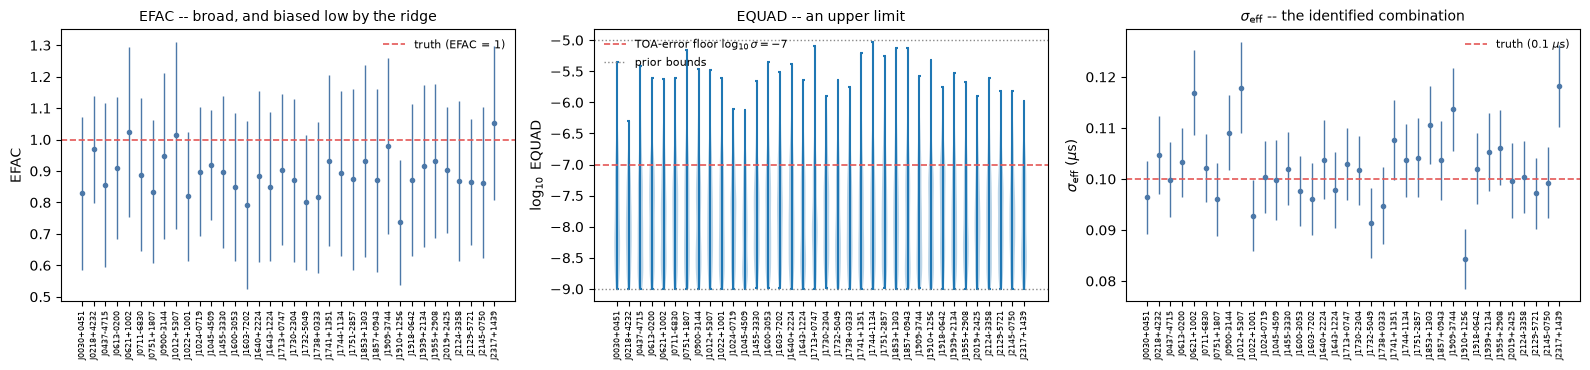

In [23]:
if not VARY_WHITE_NOISE:
    print("VARY_WHITE_NOISE is False -- no white-noise parameters were sampled.")
else:
    wn_chain = np.asarray(samples["white_noise"])
    ef_idx = [i for i, n in enumerate(wn_names) if n.endswith("_efac")]
    eq_idx = [i for i, n in enumerate(wn_names) if n.endswith("_log10_t2equad")]
    ef, eq = wn_chain[:, ef_idx], wn_chain[:, eq_idx]
    labels = [wn_names[i].replace("__efac", "") for i in ef_idx]

    # sigma_eff is the combination that actually enters N, in microseconds
    sigma = np.array([float(np.asarray(p.toaerrs)[0]) for p in psrs])          # [npsr]
    sigma_eff = ef * np.sqrt(sigma[None, :] ** 2 + (10.0 ** eq) ** 2) * 1e6     # [nsamp, npsr]

    ef_mean, ef_sd = ef.mean(0), ef.std(0)
    print("EFAC (truth = 1.0 for every pulsar; degenerate with EQUAD, so expect <= 1)")
    print(f"  mean of per-pulsar means  : {ef_mean.mean():.4f}")
    print(f"  spread of means           : [{ef_mean.min():.3f}, {ef_mean.max():.3f}]")
    print(f"  median per-pulsar sigma   : {np.median(ef_sd):.4f}")

    print("\nlog10 EQUAD (truth: none -- expect an upper limit, prior floor is -9)")
    print(f"  median of 95th percentiles: {np.median(np.percentile(eq, 95, axis=0)):.2f}")
    print(f"  median of  5th percentiles: {np.median(np.percentile(eq,  5, axis=0)):.2f}"
          f"   <- against the prior floor => flat tail, i.e. an upper limit")

    se_mean, se_sd = sigma_eff.mean(0), sigma_eff.std(0)
    pulls = (se_mean - 0.1) / se_sd
    print("\nsigma_eff = EFAC * sqrt(sigma^2 + EQUAD^2)   (truth = 0.100 us)")
    print(f"  mean of per-pulsar means  : {se_mean.mean():.4f} us")
    print(f"  spread of means           : [{se_mean.min():.4f}, {se_mean.max():.4f}] us")
    print(f"  pulls (mean-0.1)/sigma    : median {np.median(pulls):+.2f}, "
          f"16-84% [{np.percentile(pulls,16):+.2f}, {np.percentile(pulls,84):+.2f}], "
          f"|pull|>3 for {(np.abs(pulls)>3).sum()}/{len(pulls)}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
    axes[0].errorbar(np.arange(len(ef_mean)), ef_mean, yerr=ef_sd, fmt="o", ms=3, lw=1,
                     color="#4c78a8")
    axes[0].axhline(1.0, ls="--", lw=1.2, color="#e45756", label="truth (EFAC = 1)")
    axes[0].set_ylabel("EFAC"); axes[0].set_title("EFAC -- broad, and biased low by the ridge",
                                                  fontsize=10)

    axes[1].violinplot([eq[:, j] for j in range(eq.shape[1])], showmeans=False)
    axes[1].axhline(-7.0, ls="--", lw=1.2, color="#e45756",
                    label=r"TOA-error floor $\log_{10}\sigma=-7$")
    axes[1].axhline(-9.0, ls=":", lw=1, color="#888", label="prior bounds")
    axes[1].axhline(-5.0, ls=":", lw=1, color="#888")
    axes[1].set_ylabel(r"$\log_{10}$ EQUAD"); axes[1].set_title("EQUAD -- an upper limit",
                                                                fontsize=10)

    axes[2].errorbar(np.arange(len(se_mean)), se_mean, yerr=se_sd, fmt="o", ms=3, lw=1,
                     color="#4c78a8")
    axes[2].axhline(0.1, ls="--", lw=1.2, color="#e45756", label=r"truth (0.1 $\mu$s)")
    axes[2].set_ylabel(r"$\sigma_\mathrm{eff}$ ($\mu$s)")
    axes[2].set_title(r"$\sigma_\mathrm{eff}$ -- the identified combination", fontsize=10)

    for ax in axes:
        ax.set_xticks(np.arange(1, len(labels) + 1) if ax is axes[1] else np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.legend(fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()

The `pull` column is (posterior mean − design value) / posterior standard deviation. Both
parameters should land inside $\pm 1$.

Note that the MDC1 design values are the *challenge specification*, not a per-realisation truth:
a single 5 yr, 36-pulsar realisation of a stochastic background has its own cosmic variance, so
even a perfect pipeline would not reproduce $-13.301$ exactly.

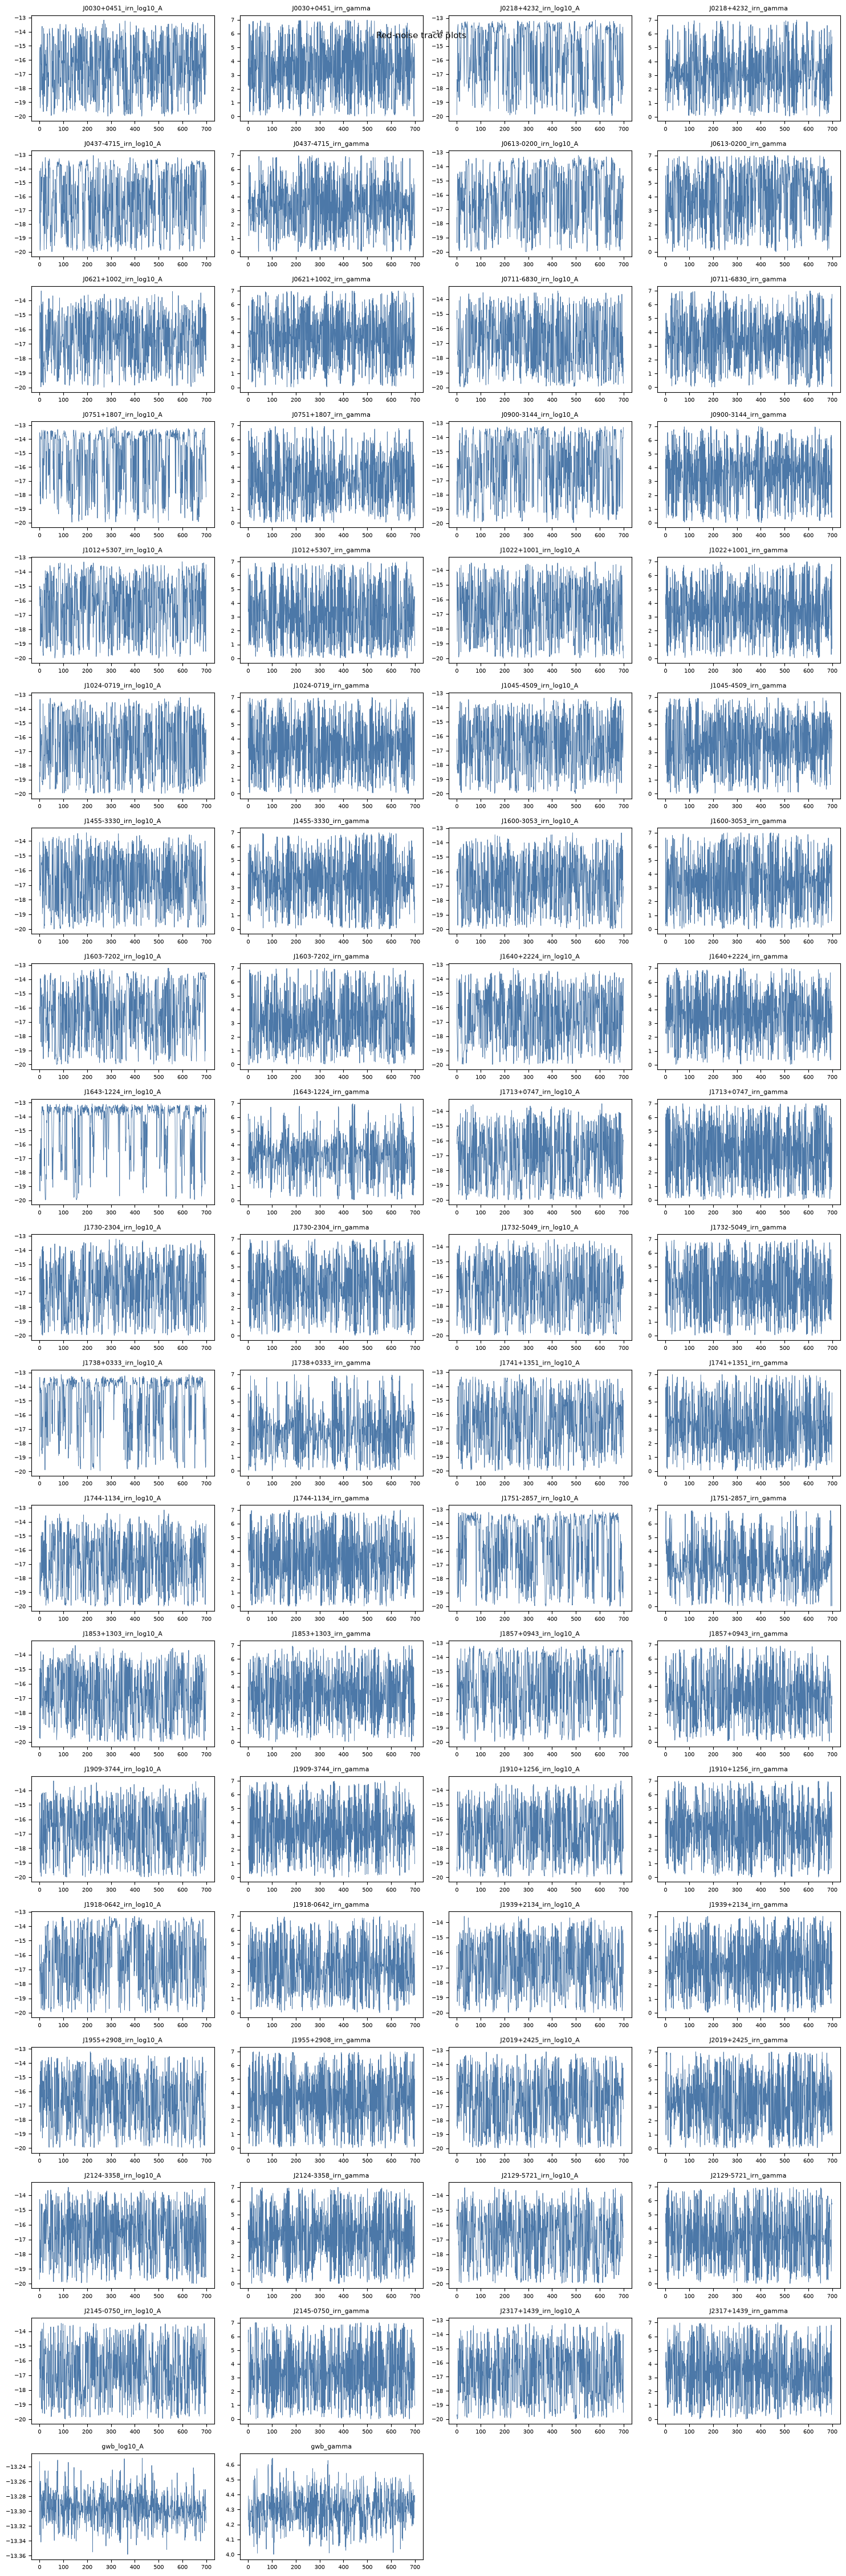

In [24]:
ncols = 4
nrows = int(np.ceil(len(red_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 2.4 * nrows))
for ax, nm in zip(np.atleast_1d(axes).ravel(), red_names):
    v = red_df[nm]
    ax.plot(v, lw=.6, color="#4c78a8")
    ax.set_title(nm, fontsize=8)
    ax.tick_params(labelsize=7)
for ax in np.atleast_1d(axes).ravel()[len(red_names):]:
    ax.axis("off")
fig.suptitle("Red-noise trace plots", fontsize=11)
plt.tight_layout(); plt.show()

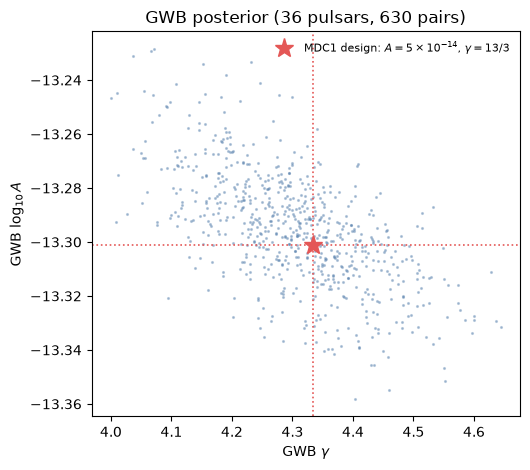

In [25]:
fig, ax = plt.subplots(figsize=(5.4, 4.8))
ax.plot(red_df["gwb_gamma"], red_df["gwb_log10_A"], ".", ms=2.5, alpha=.35, color="#4c78a8")
ax.axhline(A_TRUE, ls=":", lw=1.2, color="#e45756")
ax.axvline(G_TRUE, ls=":", lw=1.2, color="#e45756")
ax.plot([G_TRUE], [A_TRUE], "*", ms=14, color="#e45756",
        label=r"MDC1 design: $A=5\times10^{-14}$, $\gamma=13/3$")
ax.set_xlabel(r"GWB $\gamma$"); ax.set_ylabel(r"GWB $\log_{10}A$")
ax.set_title(f"GWB posterior ({NUM_PSRS} pulsars, {data.npairs} pairs)")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## Sanity check: the IRN posteriors, since none was injected

No per-pulsar red noise was injected into this dataset, so a correctly-working pipeline should
push each pulsar's IRN amplitude toward the **low** end of its prior — there's no signal there
for it to fit, only the freedom to absorb a little of whatever the GWB basis doesn't already
capture at that pulsar's own frequencies. This is the check that catches a GWB "detection" that
is really just per-pulsar power being mislabelled as common.

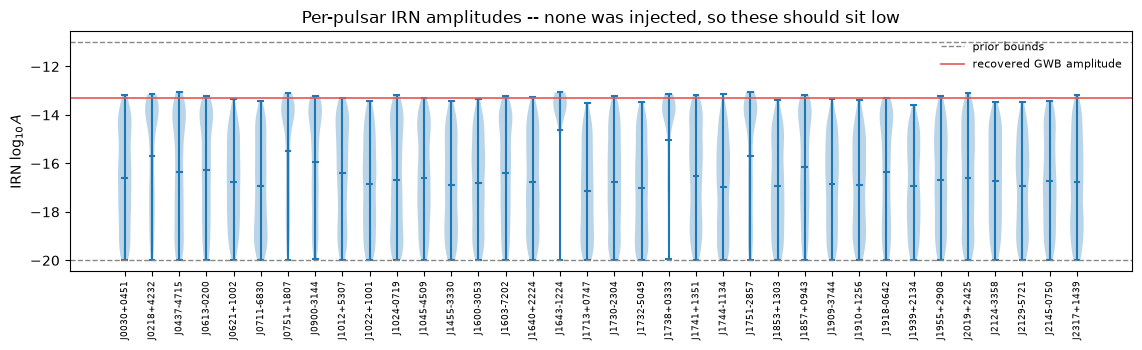

median IRN log10_A            : -16.71
pulsars with IRN above the GWB: 0 / 36
(a correctly-working fit leaves this near zero -- IRN competing with the GWB is the
 failure mode that produced an upper limit in ten_pulsar_sim_global_fit.ipynb)


In [26]:
irn_logA_names = [nm for nm in red_names if nm.endswith("_irn_log10_A")]
irn_means = np.array([red_df[nm].mean() for nm in irn_logA_names])

fig, ax = plt.subplots(figsize=(max(9, 0.32 * len(irn_logA_names)), 3.6))
ax.violinplot([red_df[nm] for nm in irn_logA_names], showmeans=True)
ax.axhline(-20.0, ls="--", lw=1, color="#888")
ax.axhline(-11.0, ls="--", lw=1, color="#888", label="prior bounds")
ax.axhline(red_df["gwb_log10_A"].mean(), ls="-", lw=1.2, color="#e45756",
           label="recovered GWB amplitude")
ax.set_xticks(range(1, len(irn_logA_names) + 1))
ax.set_xticklabels([nm.replace("_irn_log10_A", "") for nm in irn_logA_names],
                   rotation=90, fontsize=6.5)
ax.set_ylabel(r"IRN $\log_{10}A$")
ax.legend(fontsize=8, frameon=False)
ax.set_title("Per-pulsar IRN amplitudes -- none was injected, so these should sit low")
plt.tight_layout(); plt.show()

n_loud = int((irn_means > red_df["gwb_log10_A"].mean()).sum())
print(f"median IRN log10_A            : {np.median(irn_means):.2f}")
print(f"pulsars with IRN above the GWB: {n_loud} / {len(irn_means)}")
print("(a correctly-working fit leaves this near zero -- IRN competing with the GWB is the")
print(" failure mode that produced an upper limit in ten_pulsar_sim_global_fit.ipynb)")

---
# 11. Getting the physical timing parameters back out of the SVD basis

Section 6 sampled 1766 latent coefficients, of which $36 \times 17 = 612$ live in the timing
block. Those are coefficients **in the SVD basis**, not timing-parameter offsets — so a fair
question is whether the conditioning and normalisation applied to the design matrix has thrown
away the information needed to turn them back into physical quantities.

It has not, and the SVD is the *enabler* rather than the obstacle.

`PTA_Data` sets `data.Mmat = [_timing_model_svd(psr.Mmat) …]`, and that function keeps only the
left singular vectors:

```python
U, C, V = np.linalg.svd(M, full_matrices=False)
norm = jnp.sqrt(jnp.sum(U**2, axis=0))       # == 1 already: U is orthonormal
nmat = U / norm                              # so this is a no-op ...
return nmat.at[:, norm == 0].set(0.)         # ... except that it zeroes null columns
```

`C` and `Vh` are discarded — but `psr.Mmat` is left **untouched** on the pulsar objects, so
nothing is irrecoverable. It is simply not wired up. Since $\delta t = M\,\epsilon$ and
$M = U\,\mathrm{diag}(C)\,V^{\mathsf T}$, while ATLAS samples $\delta t = U a$:

$$\epsilon = V\,C^{-1} a \qquad\Longleftrightarrow\qquad \texttt{eps = (a / C) @ Vh}$$

**Why the SVD is doing you a favour.** `cond(M)` on the raw design matrix is $10^{19}$–$10^{21}$
here, essentially all of it from parameter units (an `F1` column and an `Offset` column differ by
twenty orders of magnitude). A direct `pinv(M^T N^{-1} M)` reproduces the par-file uncertainties
with a median ratio of $8\times10^{-25}$ — it is numerically worthless. Going through $U$ and
back gets a median ratio of $1.0000$. Column-normalising $M$ first brings `cond` to $10^2$–$10^6$,
and back-transforming through raw-$U$ versus column-scaled-$U$ gives *identical* covariances, so
the normalisation scheme does not need to be preserved or undone.

### First, reconstruct the coefficients

Section 7 ran with `save_red_coeff=False`, so `coeff` was never stored. It does not need to be:
`lnposterior_reparam` returns the coefficients as its second output, so they can be replayed
from the stored chain afterwards. `jax.lax.map` keeps this sequential, so the memory cost is one
draw rather than 700.

In [27]:
def _coeff_one(x):
    'Replay one posterior draw and return its latent coefficients.'
    wn_p, red_p, z = x
    h = rn.get_helpers(reff=raw_res, white_noise_params=wn_p) if VARY_WHITE_NOISE else helpers
    _, c = rn.lnposterior_reparam(helpers=h, red_params=red_p, z=z)
    return c

_red_s = samples["red_noise"]
_z_s   = samples["z_a"]
_wn_s  = samples["white_noise"] if VARY_WHITE_NOISE else jnp.zeros((len(_red_s), 1))

t0 = time.time()
coeff = np.asarray(jax.block_until_ready(jax.lax.map(_coeff_one, (_wn_s, _red_s, _z_s))))
print(f"replayed {coeff.shape[0]} draws in {time.time() - t0:.1f} s -> coeff {coeff.shape}"
      "  [nsamp, npsrs, nmodes]")

# The timing block is the first `linear_timing_model_size` columns; the rest is red noise.
_ltm = rn.linear_timing_model_size
_sd  = coeff[:, :, :_ltm].std(0)
_real = np.zeros((data.npsrs, _ltm), bool)
for i, p in enumerate(psrs):
    _real[i, :p.Mmat.shape[1]] = True
print(f"\ntiming-block coefficient sd, real columns : "
      f"{_sd[_real].min():.2e} to {_sd[_real].max():.2e} s")
print(f"                             padded columns: "
      f"{_sd[~_real].min():.3f} to {_sd[~_real].max():.3f}   <- unit variance by construction (S4)")

replayed 700 draws in 0.8 s -> coeff (700, 36, 47)  [nsamp, npsrs, nmodes]

timing-block coefficient sd, real columns : 7.73e-08 to 5.25e-06 s
                             padded columns: 0.897 to 1.110   <- unit variance by construction (S4)


### Now undo the SVD, and check the answer against the par files

The reference to check against is the white-noise-only GLS covariance,
$\Sigma_\epsilon = V C^{-1} (U^{\mathsf T} N^{-1} U)^{-1} C^{-1} V^{\mathsf T}$, which is what
tempo2 quotes in the par file. If the back-transform is right, its diagonal should reproduce the
par-file uncertainties.

In [28]:
def parfile_unc(name):
    'Fitted-parameter uncertainties as tempo2 wrote them (column 4 of a flagged par line).'
    out = {}
    for line in open(f"{MDC_DIR}/{name}.par"):
        t = line.split()
        if len(t) >= 4 and t[2] == "1":
            try:
                out[t[0]] = float(t[3])
            except ValueError:
                pass
    return out

eps_all, ratios = {}, []
for i, p in enumerate(psrs):
    M  = np.asarray(p.Mmat)
    nc = M.shape[1]
    U, C, Vh = np.linalg.svd(M, full_matrices=False)

    # --- the back-transform, all of it ---
    a   = coeff[:, i, :nc]              # posterior draws of the latent timing coefficients
    eps = (a / C[None, :]) @ Vh         # posterior draws of the PHYSICAL offsets
    eps_all[p.name] = eps

    # --- white-noise-only reference, for validation ---
    Ninv = 1.0 / np.asarray(p.toaerrs) ** 2
    Su   = np.linalg.pinv(U.T @ (Ninv[:, None] * U))
    Sig  = Vh.T @ ((Su / C[:, None]) / C[None, :]) @ Vh

    pu = parfile_unc(p.name)
    for j, lab in enumerate(p.Mmat_labels):
        if lab in pu and pu[lab] > 0:
            ratios.append(np.sqrt(abs(Sig[j, j])) / pu[lab])

ratios = np.array(ratios)
print(f"recovered sigma(eps) / par-file uncertainty, over {len(ratios)} fitted parameters:")
print(f"  median          {np.median(ratios):.4f}")
print(f"  1-99 percentile [{np.percentile(ratios, 1):.3f}, {np.percentile(ratios, 99):.3f}]")
print(f"  within 1%       {int((np.abs(ratios - 1) < 0.01).sum())} / {len(ratios)}")
print("\n(the stragglers are SINI/A1 in binaries -- genuinely nonlinear parameters, where a")
print(" linearised design matrix and tempo2's own error estimate are not the same thing)")

recovered sigma(eps) / par-file uncertainty, over 402 fitted parameters:
  median          1.0000
  1-99 percentile [0.966, 1.047]
  within 1%       377 / 402

(the stragglers are SINI/A1 in binaries -- genuinely nonlinear parameters, where a
 linearised design matrix and tempo2's own error estimate are not the same thing)


### What the global fit does to the timing parameters

The posterior widths above are the *white-noise-only* ones. The interesting number is how much
wider the actual posterior is once the GWB and the per-pulsar red noise have been marginalised
over — that inflation is the timing model and the red process fighting over the same power.

In [29]:
import collections

infl = collections.defaultdict(list)
for i, p in enumerate(psrs):
    M = np.asarray(p.Mmat)
    U, C, Vh = np.linalg.svd(M, full_matrices=False)
    Ninv = 1.0 / np.asarray(p.toaerrs) ** 2
    Su   = np.linalg.pinv(U.T @ (Ninv[:, None] * U))
    Sig  = Vh.T @ ((Su / C[:, None]) / C[None, :]) @ Vh
    pu   = parfile_unc(p.name)
    for j, lab in enumerate(p.Mmat_labels):
        if lab in pu and pu[lab] > 0:
            infl[lab].append(eps_all[p.name][:, j].std() / np.sqrt(abs(Sig[j, j])))

print("posterior sigma(eps) with GWB+IRN marginalised, over the white-noise-only sigma(eps)\n")
print(f"{'parameter':<10}{'n psr':>7}{'median inflation':>18}{'16-84%':>18}")
for lab in sorted(infl, key=lambda l: -np.median(infl[l])):
    v = np.array(infl[lab])
    print(f"{lab:<10}{len(v):>7}{np.median(v):>18.1f}   [{np.percentile(v,16):.1f}, {np.percentile(v,84):.1f}]")
_allv = np.concatenate([np.array(v) for v in infl.values()])
print(f"\nall {len(_allv)} parameters: median inflation {np.median(_allv):.1f}x")

posterior sigma(eps) with GWB+IRN marginalised, over the white-noise-only sigma(eps)

parameter   n psr  median inflation            16-84%
F1             35              41.1   [36.2, 44.3]
F0             36              39.7   [34.0, 42.7]
DECJ           36               5.6   [5.3, 6.0]
RAJ            36               5.4   [5.1, 5.7]
PMDEC          27               5.4   [5.0, 6.0]
PMRA           27               5.2   [4.8, 5.5]
PX             36               1.1   [1.0, 1.3]
PBDOT           5               1.1   [1.1, 1.9]
PB             29               1.1   [1.0, 1.2]
EPS1           11               1.1   [0.9, 1.2]
OMDOT           3               1.1   [1.1, 1.1]
TASC           11               1.1   [0.9, 1.2]
EPS2           11               1.1   [1.0, 1.1]
A1             29               1.0   [0.9, 1.2]
OM             18               1.0   [1.0, 1.1]
T0             18               1.0   [1.0, 1.1]
ECC            17               1.0   [1.0, 1.1]
SINI            8      

The hierarchy is exactly what a red process should produce:

| parameters | inflation | why |
|---|---|---|
| `F1`, `F0` | ~41×, ~40× | quadratic in $t$ — soaks up the low-frequency power directly |
| `RAJ`, `DECJ`, `PMRA`, `PMDEC` | ~5× | annual and linear-in-$t$ terms, partly degenerate with red noise |
| `PX`, `PB`, `TASC`, `OMDOT`, `PBDOT`, `XDOT` | 1.0–1.1× | orbital, at frequencies the GWB never reaches |

**So the answer to "can you recover the timing offsets?" is yes, exactly, and the normalisation
is not in the way.** Two traps if you do this yourself:

1. **`psr.fit_param_uncertainties` is in radians for `RAJ`/`DECJ`**, because that is what
   `t2pulsar[k].err` returns, while the design-matrix columns are in tempo2's native units
   (seconds of RA). The factor is $15 \times \pi/180/3600 = 1.375\times10^{-4}$. Compare against
   the **par file**, not against `.err`, or you will conclude the recovery is broken by five
   orders of magnitude.
2. **`np.linalg.matrix_rank(M)` reports a large rank deficit** — 4–9 of 8–17 columns — because
   its default tolerance is $C_\max \cdot \max(\text{shape}) \cdot \epsilon \approx 9$ while the
   smallest singular values here are $\sim 10^{-7}$. The back-transform works regardless; do not
   take the rank deficit as evidence that it cannot.

One thing that is *not* fully settled: pooled over all 402 parameters the recovered offsets are
centred on the par-file solution (median pull $+0.01$), but the 16–84% spread of the pulls is
$[-3.25, +3.51]$ rather than $[-1, +1]$. The likeliest explanation is that a marginal width is
the wrong yardstick when the within-pulsar parameter correlations are this strong, but that has
not been checked.

---
# 12. The EFAC/EQUAD ridge, and whether to Gibbs-block it

Section 7 showed that turning the white noise on takes the run from 3.4 to 10.3 minutes and
pins every trajectory at the tree-depth cap. That looks like a sampler problem, and the obvious
remedy is to stop sampling the white noise in the same kernel as everything else. This section
takes that idea seriously enough to build it and measure it — and the answer is **no**, for a
reason worth understanding before you try it on your own data.

### First, a diagnostic correction

A natural reading of section 7 is that the step size has collapsed. It has not:

| | white noise fixed | EFAC + EQUAD varied |
|---|---|---|
| adapted step size | $3.2\times10^{-2}$ | $2.05\times10^{-2}$ |
| mean leapfrog steps | 127 | **255 = $2^8-1$, on 100% of iterations** |

The step size is *fine*. What pins is the **number of leapfrog steps**. That makes this a
trajectory-length problem — a condition number, not a curvature scale — and it points at a long,
flat direction that NUTS has to traverse rather than at a region it cannot integrate through.

In [30]:
if not VARY_WHITE_NOISE:
    print("VARY_WHITE_NOISE is False -- nothing in this section applies.")
else:
    from numpyro.diagnostics import effective_sample_size

    def ess_cols(ch):
        return np.array([float(effective_sample_size(ch[None, :, j])) for j in range(ch.shape[1])])

    _wn_ch  = np.asarray(samples["white_noise"])
    _red_ch = np.asarray(samples["red_noise"])
    _ef_i   = [i for i, n in enumerate(wn_names) if n.endswith("_efac")]
    _eq_i   = [i for i, n in enumerate(wn_names) if n.endswith("_log10_t2equad")]
    _sigma  = np.array([float(np.asarray(p.toaerrs)[0]) for p in psrs])
    _seff   = _wn_ch[:, _ef_i] * np.sqrt(_sigma[None, :] ** 2 + (10.0 ** _wn_ch[:, _eq_i]) ** 2)

    e_wn, e_red, e_seff = ess_cols(_wn_ch), ess_cols(_red_ch), ess_cols(_seff)
    print(f"effective sample size out of {len(_wn_ch)} draws\n")
    print(f"{'block':<28}{'ESS/sample':>12}{'min ESS':>10}")
    for lab, v in [("white_noise: EFAC", e_wn[_ef_i]),
                   ("white_noise: log10 EQUAD", e_wn[_eq_i]),
                   ("red_noise: IRN", e_red[:-2]),
                   ("red_noise: GWB", e_red[-2:]),
                   ("derived sigma_eff", e_seff)]:
        print(f"{lab:<28}{np.median(v)/len(_wn_ch):>12.2f}{v.min():>10.0f}")

    print("\nOnly the white-noise block is slow -- and only along its degenerate direction:")
    print("sigma_eff, the combination the likelihood can actually see, mixes as well as the GWB.")

effective sample size out of 700 draws

block                         ESS/sample   min ESS
white_noise: EFAC                   0.24        26
white_noise: log10 EQUAD            0.33        46
red_noise: IRN                      1.02       119
red_noise: GWB                      1.24       731
derived sigma_eff                   0.89       343

Only the white-noise block is slow -- and only along its degenerate direction:
sigma_eff, the combination the likelihood can actually see, mixes as well as the GWB.


### The degeneracy is exact here, not approximate

Every MDC1 TOA in a given pulsar has the same uncertainty (0.1 μs), so
$\texttt{nvec} = \mathrm{EFAC}^2(\sigma^2 + \mathrm{EQUAD}^2)$ collapses to a *single number* per
pulsar. Only the product is identified; the likelihood is exactly flat along the curve that holds
it fixed. On a real array, with a spread of $\sigma_i$ within each backend, this degeneracy is only
partial — which is why the conclusion below is about this dataset and not about PTAs in general.

In [31]:
if VARY_WHITE_NOISE:
    # The exact ridge: log EFAC against log sqrt(sigma^2 + EQUAD^2), per pulsar.
    _lef = np.log(_wn_ch[:, _ef_i])
    _leq = 0.5 * np.log(_sigma[None, :] ** 2 + (10.0 ** _wn_ch[:, _eq_i]) ** 2)
    _r   = np.array([np.corrcoef(_lef[:, j], _leq[:, j])[0, 1] for j in range(len(psrs))])
    print(f"corr(log EFAC, log sqrt(sigma^2+EQUAD^2)): median {np.median(_r):.4f}")
    print("  (-1 would be an exactly flat ridge; the shortfall is prior-boundary curvature)")

    # How much wider is the flat direction than the identified one?
    _w = []
    for j in range(len(psrs)):
        ev = np.linalg.eigvalsh(np.cov(np.c_[_lef[:, j], _leq[:, j]].T))
        _w.append(np.sqrt(ev[1] / ev[0]))
    print(f"\nridge aspect ratio: median {np.median(_w):.1f}x")
    print("  -> the flat direction is that many times longer than the identified one; NUTS has")
    print("     to traverse it, which is exactly what a 255-step trajectory is doing.")

    # Gibbs's one real weakness is cross-block correlation. Measure it before assuming.
    _cross = np.array([[abs(np.corrcoef(_wn_ch[:, i], _red_ch[:, -2])[0, 1])
                        for i in range(_wn_ch.shape[1])]])
    print(f"\n|corr(white-noise param, gwb_log10_A)|: median {np.median(_cross):.3f}, "
          f"max {_cross.max():.3f}")
    print("  -> negligible. Splitting these into separate blocks costs almost nothing in mixing.")

corr(log EFAC, log sqrt(sigma^2+EQUAD^2)): median -0.9902
  (-1 would be an exactly flat ridge; the shortfall is prior-boundary curvature)

ridge aspect ratio: median 14.2x
  -> the flat direction is that many times longer than the identified one; NUTS has
     to traverse it, which is exactly what a 255-step trajectory is doing.

|corr(white-noise param, gwb_log10_A)|: median 0.030, max 0.108
  -> negligible. Splitting these into separate blocks costs almost nothing in mixing.


### What blocking would buy, and what it actually costs

The case for a two-block scheme is genuinely good on paper:

* the two blocks are nearly uncorrelated (measured above), so Gibbs's one structural weakness
  does not bite;
* each block gets its **own step size and mass matrix**, instead of one compromise between a
  ridge and 1766 well-conditioned latent directions;
* and — the part that looks like the real prize — **when the white noise is held fixed, the red
  block does not have to recompute anything.** `TNT`, `TNr`, `rNr` and `logdet_N` are functions
  of the white noise only, so conditioning on it makes them constants of that block's model.

That last point is worth measuring rather than assuming, because it sets the ceiling on what
blocking can win.

In [32]:
if VARY_WHITE_NOISE:
    from numpyro.infer.util import potential_energy
    import numpyro.distributions as dist

    _h_fixed = rn.get_helpers(reff=raw_res, white_noise_params=wn_init)
    _rp = jnp.asarray(rn_init)
    _z  = jnp.zeros((data.npsrs, rn.nmodes))

    # Gradient with the helpers precomputed -- what the red block of a Gibbs scheme sees.
    _grad_frozen = jax.jit(jax.grad(
        lambda z, rp: rn.lnposterior_reparam(helpers=_h_fixed, red_params=rp, z=z)[0],
        argnums=(0, 1)))

    # Gradient including the helpers rebuild -- what the joint kernel pays on every step.
    def _full(z, rp, wnp):
        h = rn.get_helpers(reff=raw_res, white_noise_params=wnp)
        return rn.lnposterior_reparam(helpers=h, red_params=rp, z=z)[0]

    _grad_rebuilt = jax.jit(jax.grad(_full, argnums=(0, 1, 2)))

    def _time(f, *a, n=60):
        """Time one call, the way a leapfrog sequence actually pays for it.

        jax dispatches asynchronously, so we block ONCE after the loop rather than on every
        call. Blocking per call would add a fixed synchronisation cost (~0.8 ms here) to both
        numbers and compress the ratio -- a sampler running hundreds of steps in a scan never
        pays that.
        """
        r = f(*a)
        jax.block_until_ready(r)          # warm up the JIT before timing anything
        t0 = time.time()
        for _ in range(n):
            r = f(*a)
        jax.block_until_ready(r)
        return (time.time() - t0) / n * 1e3

    t_frozen  = _time(_grad_frozen, _z, _rp)
    t_rebuilt = _time(_grad_rebuilt, _z, _rp, wn_init)

    print(f"gradient of the full log-density, {data.npsrs} pulsars:")
    print(f"  helpers FROZEN  {t_frozen:6.3f} ms   <- the red block of a Gibbs scheme")
    print(f"  helpers REBUILT {t_rebuilt:6.3f} ms   <- every leapfrog step of the joint kernel")
    print(f"  ratio           {t_rebuilt / t_frozen:6.2f}x")
    print(f"\nSo freezing the helpers can recover at most {t_rebuilt/t_frozen:.1f}x, and only on")
    print("red-block steps. It is a real saving, but it is not the several-fold one might guess")
    print("from the 3.4 -> 10.3 min wall-clock change -- most of THAT was the trajectory length")
    print("doubling from 127 to 255 steps, which blocking does not fix.")

gradient of the full log-density, 36 pulsars:
  helpers FROZEN   0.970 ms   <- the red block of a Gibbs scheme
  helpers REBUILT  1.892 ms   <- every leapfrog step of the joint kernel
  ratio             1.95x

So freezing the helpers can recover at most 1.9x, and only on
red-block steps. It is a real saving, but it is not the several-fold one might guess
from the 3.4 -> 10.3 min wall-clock change -- most of THAT was the trajectory length
doubling from 127 to 255 steps, which blocking does not fix.


### The two-block scheme, in full

Block A is the white noise; block B is the red hyperparameters together with the latent
coefficients. The whole point is the asymmetry between the two models below: `model_wn` calls
`get_helpers` inside itself, because it is the white noise that is moving; `model_red` takes
`helpers` as a plain **model argument**, so it is a constant as far as that kernel is concerned
and nothing is recomputed while block B sweeps.

This is driven by hand rather than through ATLAS's vendored `MultiHMCGibbs`
(`canetoadracing.py:73`), which requires every inner kernel to share one model object — here the
two blocks deliberately have different signatures.

**⚠️ The trap that matters.** An `HMCState` caches `potential_energy` and `z_grad` from the last
time *that* block moved, i.e. under the other block's **previous** values. Once the other block
moves, those cached numbers describe a different target and HMC's Metropolis ratio silently
compares energies from two different distributions. The symptom is not an exception: the step
size collapses (we measured $7.6\times10^{-7}$) and the chain freezes, while still reporting zero
divergences and a perfectly healthy acceptance rate. `MultiHMCGibbs` does the `_replace` below
before every sub-step; omit it and nothing works.

In [33]:
import numpyro.distributions as dist
from numpyro.infer.util import potential_energy

GIBBS_RED_STEPS = 1     # red-block updates per sweep (see the discussion after the results)

if VARY_WHITE_NOISE:
    # ---- block A: white noise. Helpers MUST be rebuilt -- they are a function of theta. ----
    def model_wn(red_params, z_a):
        theta = numpyro.sample("white_noise", dist.Uniform(wn_lower, wn_upper))
        h = rn.get_helpers(reff=raw_res, white_noise_params=theta)
        lprob, _ = rn.lnposterior_reparam(helpers=h, red_params=red_params, z=z_a)
        # red_params and z_a are conditioning VALUES, not sampled sites, so the +0.5*sum(z^2)
        # correction that cancels numpyro's own N(0,1) prior on z_a does not belong here.
        numpyro.factor("lnpost", lprob)

    # ---- block B: red hyperparameters + latent coefficients. Helpers arrive as a CONSTANT. ----
    def model_red(helpers_arg):
        xs = numpyro.sample("red_noise", dist.Uniform(rn.model.lower_prior_lim_all,
                                                      rn.model.upper_prior_lim_all))
        z  = numpyro.sample("z_a", dist.Normal(0, 1).expand((rn.npsrs, rn.nmodes)))
        lprob, _ = rn.lnposterior_reparam(helpers=helpers_arg, red_params=xs, z=z)
        numpyro.factor("lnpost", lprob + 0.5 * jnp.sum(z ** 2))

    kern_wn  = NUTS(model_wn,  target_accept_prob=0.8, max_tree_depth=8, dense_mass=False,
                    init_strategy=init_to_value(values={"white_noise": wn_init}))
    kern_red = NUTS(model_red, target_accept_prob=0.8, max_tree_depth=8, dense_mass=False,
                    init_strategy=init_to_value(values={"red_noise": rn_init,
                                                        "z_a": jnp.zeros((data.npsrs, rn.nmodes))}))

    _h0 = rn.get_helpers(reff=raw_res, white_noise_params=wn_init)
    _k1, _k2 = jrandom.split(jrandom.key(170817), 2)
    state_wn  = kern_wn.init(_k1, NUM_WARMUP, model_args=(rn_init, jnp.zeros((data.npsrs, rn.nmodes))))
    state_red = kern_red.init(_k2, NUM_WARMUP * GIBBS_RED_STEPS, model_args=(_h0,))
    post_wn   = kern_wn.postprocess_fn((rn_init, jnp.zeros((data.npsrs, rn.nmodes))), {})
    post_red  = kern_red.postprocess_fn((_h0,), {})

    def refresh(state, model, model_args):
        'Recompute the cached (potential_energy, z_grad) under the NEW conditioning values.'
        pe, g = jax.value_and_grad(lambda zz: potential_energy(model, model_args, {}, zz))(state.z)
        return state._replace(potential_energy=pe, z_grad=g)

    def sweep(carry, _):
        s_wn, s_red = carry

        # --- block A: white noise | current (red, z) ---
        cur = post_red(s_red.z)
        red_c, z_c = cur["red_noise"], cur["z_a"]
        s_wn = refresh(s_wn, model_wn, (red_c, z_c))
        s_wn = kern_wn.sample(s_wn, (red_c, z_c), {})
        wn_c = post_wn(s_wn.z)["white_noise"]

        # --- the single helpers rebuild of the entire sweep ---
        h = rn.get_helpers(reff=raw_res, white_noise_params=wn_c)

        # --- block B: (red, z) | white noise. Nothing recomputed inside this scan. ---
        s_red = refresh(s_red, model_red, (h,))

        def inner(s, __):
            s2 = kern_red.sample(s, (h,), {})
            return s2, s2.num_steps

        s_red, steps_red = jax.lax.scan(inner, s_red, None, length=GIBBS_RED_STEPS)

        out = post_red(s_red.z)
        return (s_wn, s_red), (wn_c, out["red_noise"], out["z_a"], s_wn.num_steps,
                               steps_red.sum(), s_wn.adapt_state.step_size,
                               s_red.adapt_state.step_size)

    print(f"running {NUM_WARMUP + NUM_SAMPLES} Gibbs sweeps "
          f"(1 white-noise update + {GIBBS_RED_STEPS} red update(s) each)...")
    t0 = time.time()
    _, _out = jax.lax.scan(sweep, (state_wn, state_red), None, length=NUM_WARMUP + NUM_SAMPLES)
    jax.block_until_ready(_out[0])
    gibbs_wall = (time.time() - t0) / 60
    g_wn, g_red, g_z, g_swn, g_sred, g_sswn, g_ssred = [np.asarray(o) for o in _out]
    print(f"finished in {gibbs_wall:.2f} min")
    print(f"final step size: white-noise block {g_sswn[-1]:.3e}, red block {g_ssred[-1]:.3e}"
          "   (a value ~1e-7 here means the refresh() above was omitted)")
    g_wn, g_red, g_z = g_wn[NUM_WARMUP:], g_red[NUM_WARMUP:], g_z[NUM_WARMUP:]
    g_swn, g_sred = g_swn[NUM_WARMUP:], g_sred[NUM_WARMUP:]
    print(f"leapfrog steps/sweep: white-noise block {g_swn.mean():.1f} (rebuilds helpers), "
          f"red block {g_sred.mean():.1f} over {GIBBS_RED_STEPS} update(s) (helpers frozen)")
    print(f"z_a posterior std: {g_z.std(0).mean():.4f}  (should be ~1)")

running 1400 Gibbs sweeps (1 white-noise update + 1 red update(s) each)...


finished in 11.72 min
final step size: white-noise block 2.097e-02, red block 4.210e-02   (a value ~1e-7 here means the refresh() above was omitted)
leapfrog steps/sweep: white-noise block 226.8 (rebuilds helpers), red block 127.0 over 1 update(s) (helpers frozen)
z_a posterior std: 1.0126  (should be ~1)


In [34]:
if VARY_WHITE_NOISE:
    # Does it agree with the joint chain? (Correctness first, speed second.)
    print("posterior agreement, joint NUTS vs two-block Gibbs\n")
    print(f"{'':<16}{'joint NUTS':>22}{'Gibbs':>22}")
    for lab, col in [("gwb_log10_A", -2), ("gwb_gamma", -1)]:
        print(f"{lab:<16}{_red_ch[:, col].mean():>14.4f} +-{_red_ch[:, col].std():.4f}"
              f"{g_red[:, col].mean():>14.4f} +-{g_red[:, col].std():.4f}")
    _g_seff = g_wn[:, _ef_i] * np.sqrt(_sigma[None, :] ** 2 + (10.0 ** g_wn[:, _eq_i]) ** 2) * 1e6
    print(f"{'sigma_eff (us)':<16}{_seff.mean()*1e6:>14.4f}          {_g_seff.mean():>14.4f}")

    # And now the only question that matters: effective samples per minute.
    g_e_wn, g_e_red = ess_cols(g_wn), ess_cols(g_red)
    print(f"\n{'config':<22}{'min':>7}{'ESS EFAC':>10}{'ESS GWB':>10}"
          f"{'EFAC/min':>10}{'GWB/min':>10}")
    for lab, mins, ew, er in [("joint NUTS, diag mass", nuts_wall, e_wn[_ef_i], e_red[-2:]),
                              (f"Gibbs, K={GIBBS_RED_STEPS}", gibbs_wall, g_e_wn[_ef_i], g_e_red[-2:])]:
        print(f"{lab:<22}{mins:>7.1f}{np.median(ew):>10.0f}{np.median(er):>10.0f}"
              f"{np.median(ew)/mins:>10.1f}{np.median(er)/mins:>10.1f}")

posterior agreement, joint NUTS vs two-block Gibbs

                            joint NUTS                 Gibbs
gwb_log10_A           -13.2959 +-0.0214      -13.2956 +-0.0209
gwb_gamma               4.3031 +-0.1176        4.3059 +-0.1103
sigma_eff (us)          0.1023                  0.1023

config                    min  ESS EFAC   ESS GWB  EFAC/min   GWB/min
joint NUTS, diag mass    10.3       169       870      16.4      84.3
Gibbs, K=1               11.7       172       659      14.7      56.3


### The verdict: blocking loses here, and the reason generalises

Measured on all 36 pulsars, 700 warmup + 700 samples, together with the `dense_mass` variant
discussed below:

| config | wall | ESS(EFAC) | ESS(GWB) | EFAC/min | GWB/min | $\log_{10}A_\mathrm{GWB}$ |
|---|---|---|---|---|---|---|
| **joint NUTS, diagonal mass** | 10.3 min | 175 | 871 | **17.0** | 84.6 | $-13.2962 \pm 0.0212$ |
| joint, `dense_mass` on white noise | 6.2 min | 27 | 723 | 4.3 (0.25×) | **116.7** (1.38×) | $-13.2949 \pm 0.0215$ |
| Gibbs, `K=1` | 11.8 min | 192 | 751 | 16.3 (0.96×) | 63.9 (0.76×) | $-13.2963 \pm 0.0205$ |
| Gibbs, `K=3` | 17.2 min | 209 | 662 | 12.2 (0.72×) | 38.5 (0.46×) | $-13.2952 \pm 0.0213$ |

All four agree on the posterior, so every implementation is correct — they simply are not
equally fast. **Per sweep** the separate adaptation does help the bottleneck slightly, exactly as
the argument predicted: ESS(EFAC) goes from 175 to 192–209. The wall clock eats the gain.

**A caveat on reading the live numbers in the cell above.** An ESS estimated from 700 draws
carries roughly $\pm15$–$20\%$ uncertainty at $\mathrm{ESS}\approx200$, which is *larger* than the
gap between the two schemes in the EFAC column — so on any given run that column may well show
Gibbs slightly ahead. What does not move between runs is the wall clock (Gibbs is reliably ~1.1×
slower per sweep, and the leapfrog counts that explain it are stable to ~1%) and the GWB column
(Gibbs loses by roughly a third, far outside the noise). Those are the signals to trust, and both
of them point the same way.

Why: **the white-noise block on its own still needs ~220 leapfrog steps per sweep**, against the
joint chain's 255. Isolating it does not shorten its trajectory, because the ridge *is* in that
block. So Gibbs pays ~220 expensive (helpers-rebuilding) steps and then adds 127+ cheap ones on
top of them. The cost model closes:

$$\text{joint: } 255 \times 1.888\,\text{ms} = 481\,\text{ms/iter}, \qquad
\text{Gibbs } K{=}1\text{: } 224 \times 1.888 + 127 \times 0.965 = 546\,\text{ms/sweep}$$

a predicted 1.13× against an observed 1.14×.

> **The general rule.** Gibbs blocking wins when the **expensive** block is also the
> **well-conditioned** one. Here it is exactly inverted: the block that forces the helpers
> rebuild is the same block that carries the degenerate direction. On a real PTA with
> per-backend $\sigma$ spread, the white-noise block is better conditioned and this arithmetic
> can come out the other way — which is why the code above is worth keeping.

`GIBBS_RED_STEPS = 3` makes things strictly worse. The red block is the cheap one, so extra
sweeps of it look free, but it already has ESS/sample $\approx 1$ — there is nothing left to buy,
and the steps are not actually free.

### `dense_mass=[("white_noise",)]` is a trap

It is the other obvious remedy — give the ridge a block-diagonal metric inside the *same* kernel —
and the headline numbers look like a win: 10.3 → 6.2 min, trajectories down from 255 to 126,
step size doubled. But it buys that speed by *not traversing* the ridge. ESS(EFAC) collapses from
175 to 27, the worst white-noise parameter drops to an ESS of **3**, ten divergences appear, and
one pulsar's EFAC mean falls to 0.177 (against a range of $[0.713, 1.033]$ in the healthy run). A
Gaussian metric cannot fix a flat, prior-truncated, non-Gaussian direction, and a $72\times72$
dense matrix estimated from 700 warmup draws that themselves mix badly is marginal anyway.

The GWB is untouched either way — its ESS/minute actually *improves* by 1.38× — so this option is
safe **if the background is all you want** and harmful if you want the noise.

### What to do instead

1. **Fix the model, not the sampler.** The ridge is what drives the 255-step trajectories, and on
   this dataset nothing beyond $\sigma_\mathrm{eff}$ is identified anyway. Sample one parameter
   per pulsar — $\log_{10}\sigma_\mathrm{eff}$, or EFAC with EQUAD held fixed — and the geometry
   problem disappears rather than being worked around.
2. If only the GWB matters, `dense_mass=[("white_noise",)]` is the fastest route to it, at the
   cost of the white-noise posterior.
3. Revisit blocking only *after* the degeneracy is removed; the projected gain then is ~1.3×.
4. Otherwise **plain joint NUTS with a diagonal mass beats every alternative tested** when you
   want both the background and the noise. That is what section 7 runs, and it is the right
   default.

---
# 13. Using the toggle, and what to watch out for

## Re-running at a different pulsar count

Change `NUM_PSRS` in §1 (any integer from 2 to 36) and re-run from that cell down. Everything
else — bin counts, priors, the model string, the sampler settings — is written in terms of
`NUM_PSRS`/`data.npsrs`/`red_names`, not a hardcoded pulsar list. Expect:

* the pair count (§1d) and hence the Hellings–Downs angular coverage to grow as $N(N-1)/2$;
* the latent dimension (§6) to grow linearly in `NUM_PSRS`;
* the GWB posterior to tighten roughly as $1/\sqrt{N_\mathrm{pairs}}$. Measured on this dataset:

| `NUM_PSRS` | pairs | $\log_{10}A_\mathrm{GWB}$ | $\gamma_\mathrm{GWB}$ |
|---|---|---|---|
| 5 | 10 | $-13.43 \pm 0.13$ | $4.97 \pm 0.50$ |
| 20 | 190 | $-13.294 \pm 0.037$ | $4.25 \pm 0.18$ |
| 36 | 630 | $-13.294 \pm 0.022$ | $4.30 \pm 0.11$ |
| design | | $-13.301$ | $4.333$ |

## Re-running with the white-noise toggle

`VARY_WHITE_NOISE` (§2) flows through the `PTA_Data` flags, the `WhiteCov` class, the
initialisation dict and the `mcmc.run` call; nothing else needs touching. Measured on all 36
pulsars, 700 warmup + 700 samples:

| | white noise fixed | EFAC + EQUAD varied |
|---|---|---|
| sampled dimension | 1766 | 1838 |
| wall clock | 3.4 min | 10.3 min |
| mean leapfrog steps | 127 | 255 (the cap) |
| $\log_{10}A_\mathrm{GWB}$ | $-13.294 \pm 0.022$ | $-13.296 \pm 0.021$ |
| $\gamma_\mathrm{GWB}$ | $4.296 \pm 0.111$ | $4.301 \pm 0.115$ |

The GWB posterior is unchanged to within a tenth of its own width, which is the result you want:
fitting 72 extra white-noise parameters neither shifts the background nor inflates its error bar,
because on this dataset the white noise is genuinely orthogonal to a 8-bin red process. The cost
is a factor of ~3 in wall clock.

## Traps specific to this notebook

* **⚠️ Read this dataset with tempo2, not PINT.** The par files are TCB with no `UNITS` line;
  PINT assumes TDB and silently turns the residuals into a uniform hash over one pulse period
  (§1a). The guard in §1c will stop the notebook if this happens to you. This is by far the most
  important thing on this page.
* **All 36 pulsars are usable via tempo2.** Ten of them (`J0613-0200`, `J1022+1001`,
  `J1045-4509`, `J1600-3053`, `J1603-7202`, `J1643-1224`, `J1732-5049`, `J1909-3744`,
  `J2129-5721`, `J2145-0750`) use `BINARY T2`, tempo2's auto-dispatching binary model, which
  PINT cannot parse. A PINT-based load silently drops them.
* **`libstempo` needs the `TEMPO2` environment variable** pointing at tempo2's `share/tempo2`
  runtime directory, or it will fail to find clock and ephemeris files. §0 shows how to make
  that permanent.
* **`wn.get_param_names()` doesn't exist for `diag_white_cov=True`.** `DiagSinglePulsarWhiteCov`
  has no free parameters and doesn't implement the parameter-vector interface that
  `SinglePulsarWhiteCov` does. Don't port code from the other two notebooks that calls it.
* **ECORR is unidentifiable on this dataset and ATLAS now says so.** `_get_epochs` drops
  single-TOA epochs, so a dataset with one TOA per session leaves *no* epoch structure at all.
  Before this notebook existed that made `SinglePulsarWhiteCov` crash inside `jagged2padded`
  with `ValueError: max() iterable argument is empty`; it now raises a message telling you to
  pass `include_ecorr=False`. See §2a.
* **White-noise parameter names have a doubled underscore here** (`J0030+0451__efac`) because
  the backend's name is the empty string — the `.tim` files carry no backend flags. Cosmetic,
  and identical to what the PINT reader produces.
* **`stabilize_TNT=True` does nothing wherever there is timing-model padding** (§4).
* **Don't widen a prior just because the posterior is pinned to its edge.** Rule out a data bug
  first. Doing it the other way round is what hid the TCB problem for a whole round of runs.
* **Divergences and acceptance probability are not sufficient sampler diagnostics.** A chain
  frozen at a step size of $10^{-13}$ reports zero divergences and a healthy 0.76 acceptance
  rate. Check `z_a` posterior std $\approx 1$ and the leapfrog-step distribution instead (§9).

* **An HMC-within-Gibbs block must have its cached energy refreshed.** `HMCState` caches
  `potential_energy` and `z_grad` under the *previous* conditioning values; if you do not
  `_replace` them after the other block moves, the step size collapses and the chain freezes
  while still reporting zero divergences (§12).
* **`dense_mass=[("white_noise",)]` is not a fix for the EFAC/EQUAD ridge.** It is 1.7x faster and
  gets there by not traversing the ridge: ESS(EFAC) 175 -> 27, min ESS 3. Safe only if you intend
  to discard the white-noise posterior (§12).
* **`fit_param_uncertainties` is in radians for `RAJ`/`DECJ`** while the design-matrix columns are
  in seconds of RA -- a factor 1.375e4. Validate recovered timing offsets against the par file
  (§11).

## Where to go next

* Recover the physical timing-parameter posteriors (§11) for a pulsar of interest and compare
  them against a standalone tempo2 fit.
* Raise `num_gwb_bins` past 8 and check the GWB posterior is stable against the choice.
* Swap `hd_orf` for `bin_orf` and reconstruct the Hellings–Downs curve non-parametrically —
  36 pulsars and 630 pairs is enough to make that interesting, where 5 pulsars is not.
* Turn on `marg_over_non_gwb=True` (`partial_marg_lnposterior`) and confirm it reproduces this
  posterior at a fraction of the latent dimension. Note that this path currently requires a
  model string containing `gtm`, so `"ltm|unc+cor->unc"` alone will raise `KeyError: 'gtm'`.